# 🍷 Classificação da Qualidade de Vinhos
## Tech Challenge — Fase 2 | POSTECH DTAT

**Objetivo:** Prever se um vinho é de **alta qualidade (nota ≥ 7)** ou **baixa/média qualidade (nota < 7)** com base em suas características físico-químicas.


## 1. Imports e Configurações

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve,
                              precision_score, recall_score, f1_score)

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)


## 2. Carregamento dos Dados

In [10]:
df = pd.read_csv('WineQT.csv')
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [11]:
df.shape

(1143, 13)

In [12]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


## 3. Análise Exploratória de Dados (EDA)

### 3.1 Valores Nulos e Duplicatas

In [14]:
print("Valores nulos:")
print(df.isnull().sum())

print(f"\nRegistros duplicados: {df.duplicated().sum()}")

# Removendo a coluna Id (apenas identificador, sem valor preditivo)
# Feita após a verificação de duplicatas para não distorcer a contagem
df = df.drop(columns=['Id'])
print("\nColuna 'Id' removida.")


Valores nulos:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Registros duplicados: 0

Coluna 'Id' removida.


### 3.2 Variável Alvo

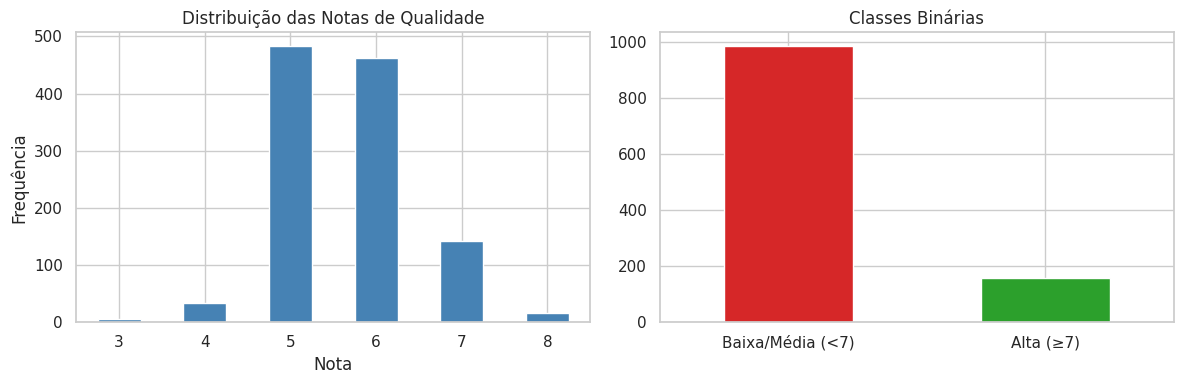

In [15]:
# Criando a classificação binária
df['quality_label'] = df['quality'].apply(lambda x: 'Alta (≥7)' if x >= 7 else 'Baixa/Média (<7)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribuição original
df['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição das Notas de Qualidade')
axes[0].set_xlabel('Nota')
axes[0].set_ylabel('Frequência')
axes[0].tick_params(axis='x', rotation=0)

# Distribuição binária
df['quality_label'].value_counts().plot(kind='bar', ax=axes[1],
    color=['#d62728', '#2ca02c'], edgecolor='white')
axes[1].set_title('Classes Binárias')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


> **Observação:** O dataset é desbalanceado — cerca de **86% das amostras** pertencem à classe Baixa/Média e apenas **14% à Alta Qualidade**. Isso deverá ser tratado no pré-processamento.


### 3.3 Distribuição das Features

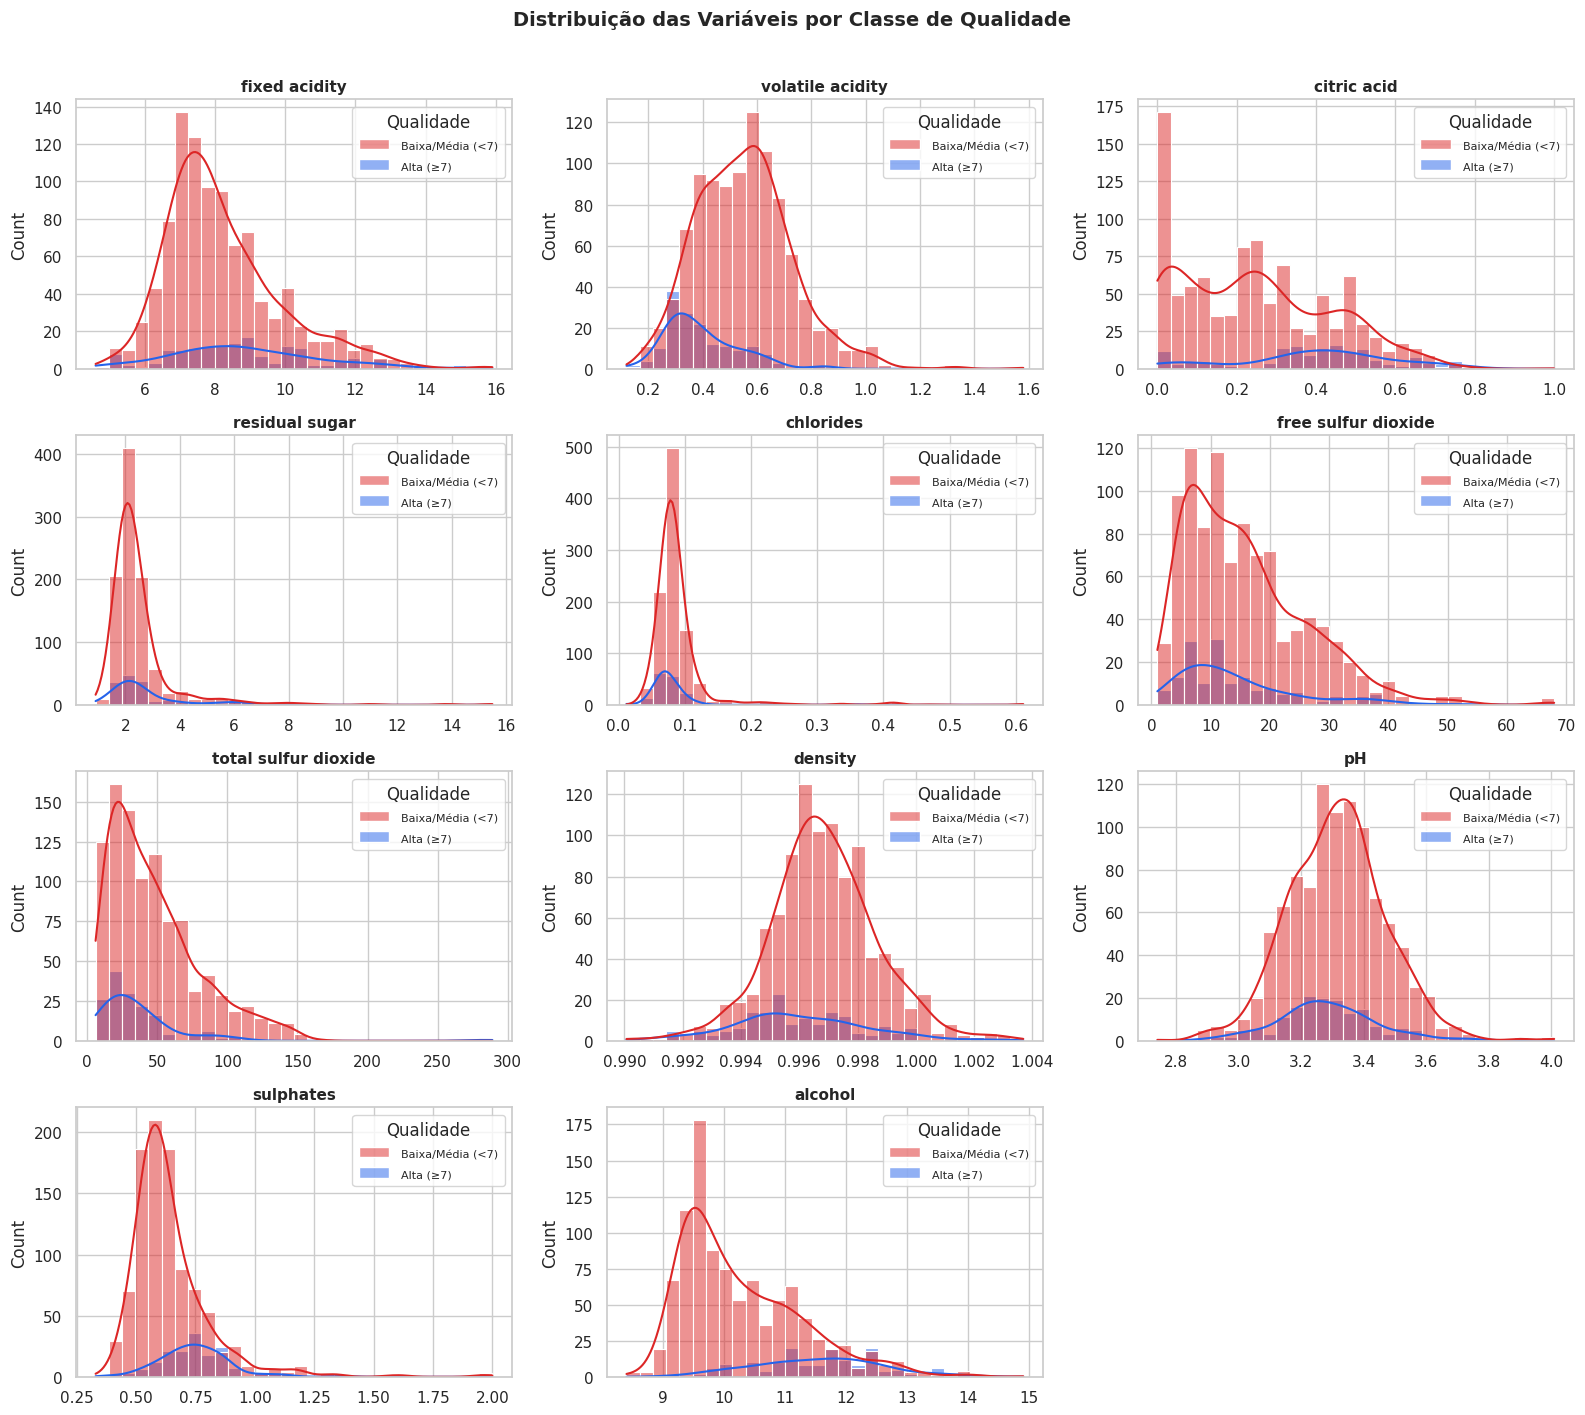

In [16]:
df['quality_label'] = df['quality'].apply(lambda x: 'Alta (≥7)' if x >= 7 else 'Baixa/Média (<7)')

features = [c for c in df.columns if c not in ['quality', 'quality_label', 'wine_type']]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    sns.histplot(
        data=df, x=col, hue='quality_label',
        kde=True, ax=ax,
        palette={'Alta (≥7)': '#2563EB', 'Baixa/Média (<7)': '#DC2626'},
        alpha=0.5, bins=30
    )
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')

    # Pega a legenda que o seaborn criou e ajusta o título
    legend = ax.get_legend()
    if legend:
        legend.set_title('Qualidade')
        for text in legend.get_texts():
            text.set_fontsize(8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das Variáveis por Classe de Qualidade', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

<Axes: >

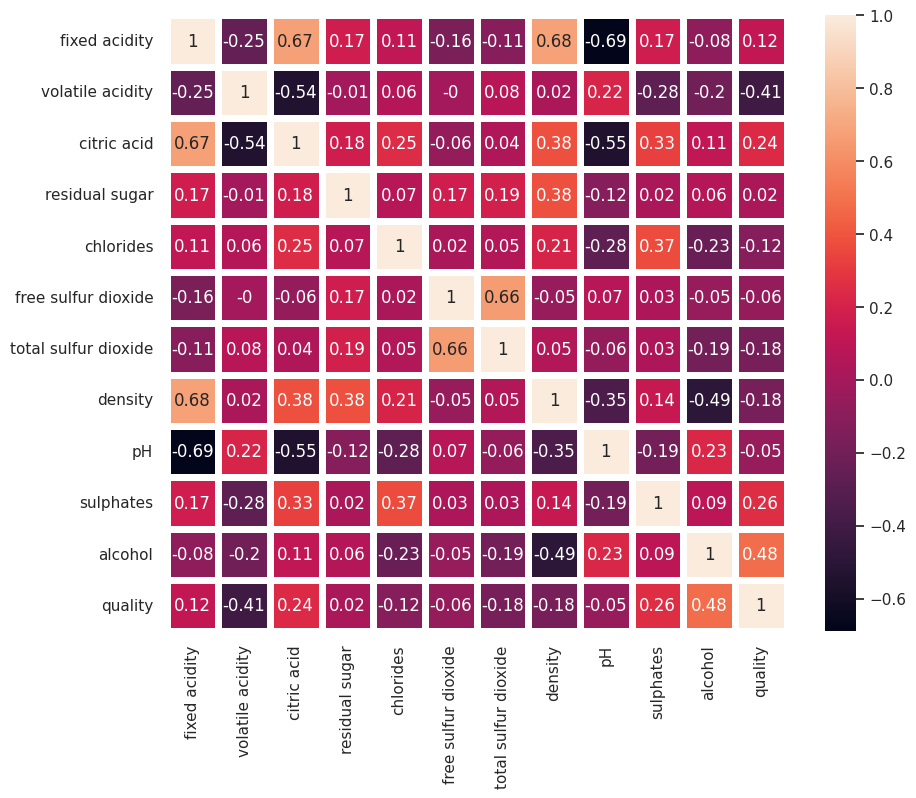

In [17]:
import seaborn as sb
correlation_matriz = df.drop(columns=['quality_label']).corr().round(2)
fix, ax = plt.subplots(figsize=(10, 8))
sb.heatmap(data = correlation_matriz, annot=True, linewidths=5, ax=ax)

### 3.4 Matriz de Correlação

### 3.5 Boxplots por Classe

/tmp/ipykernel_29604/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
/tmp/ipykernel_29604/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
/tmp/ipykernel_29604/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
/tmp/ipykernel_29604/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplo

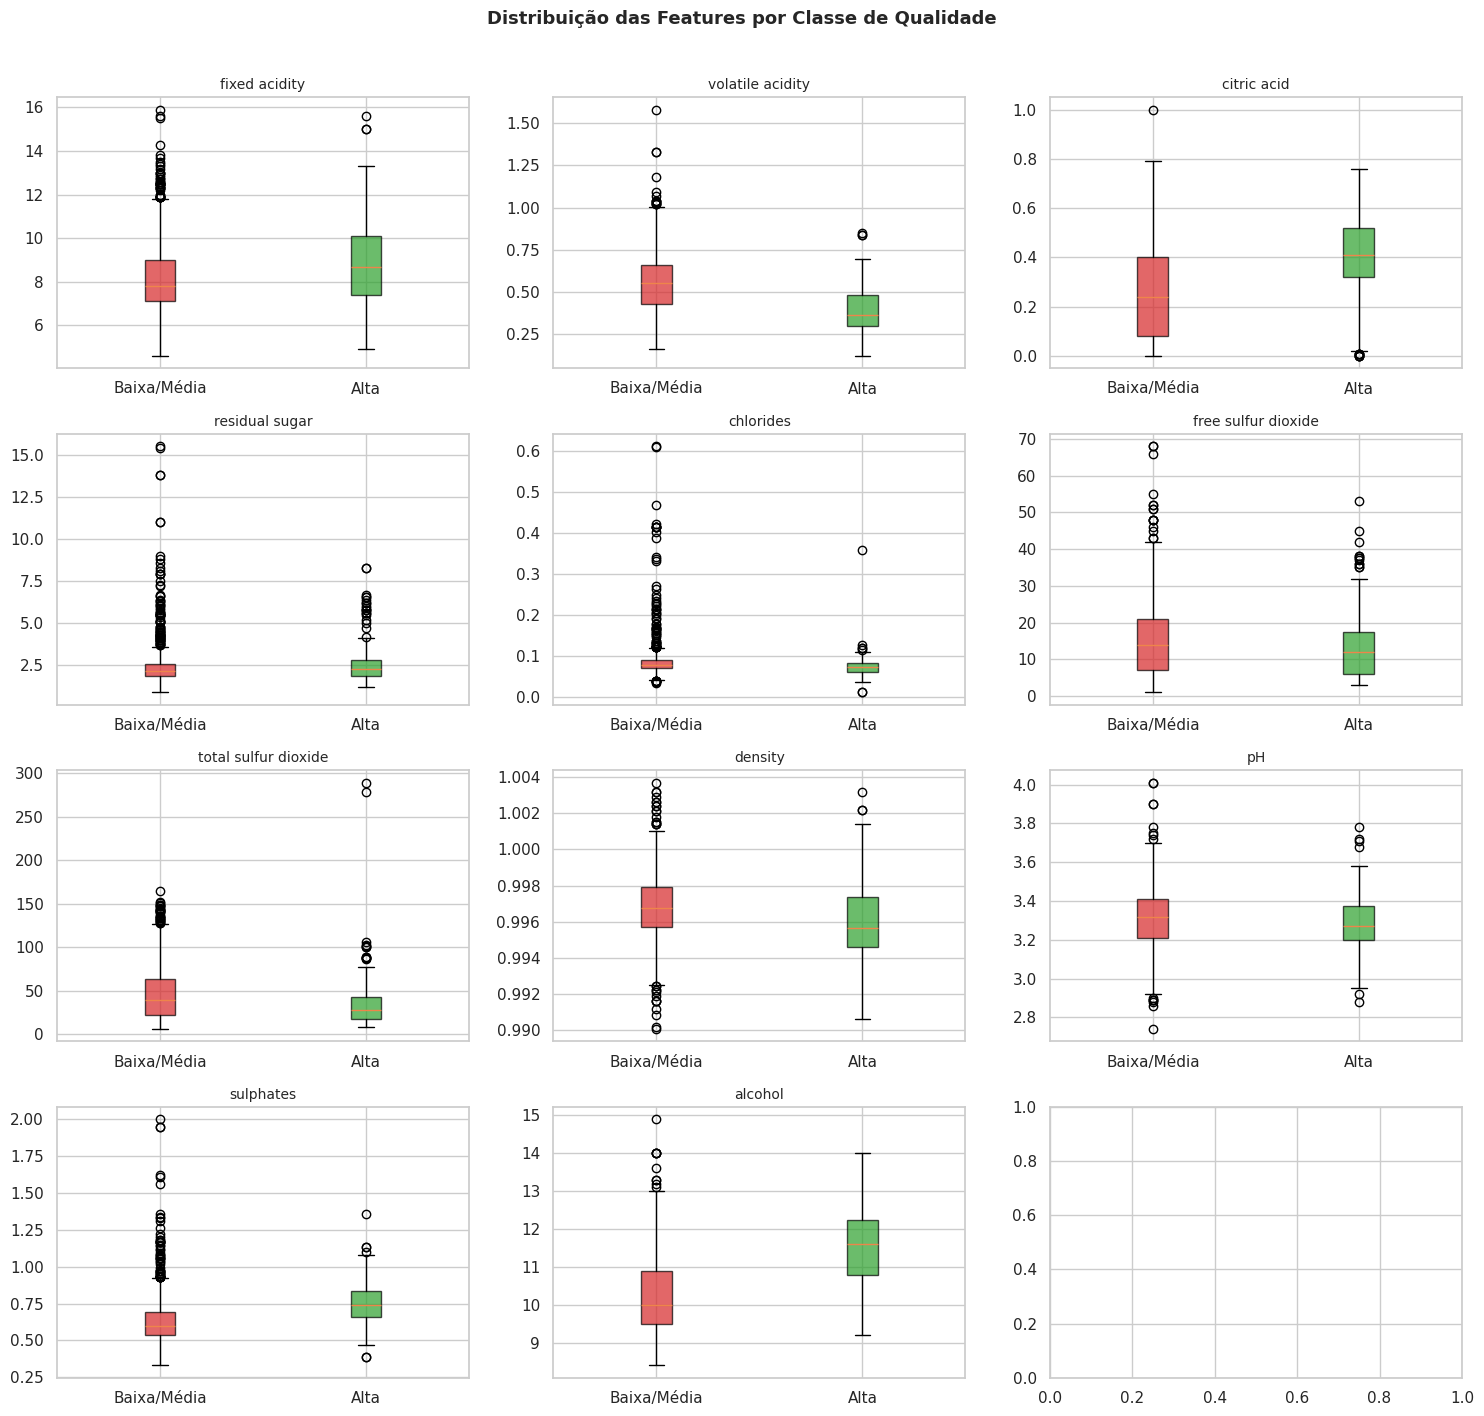

In [18]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, feat in enumerate(features):
    data = [df[df['quality_label'] == cls][feat].values for cls in ['Baixa/Média (<7)', 'Alta (≥7)']]
    bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
    bp['boxes'][0].set(facecolor='#d62728', alpha=0.7)
    bp['boxes'][1].set(facecolor='#2ca02c', alpha=0.7)
    axes[i].set_title(feat, fontsize=10)

plt.suptitle('Distribuição das Features por Classe de Qualidade', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 3.6 Principais Insights da EDA

In [20]:
correlation_quality = correlation_matriz['quality'].drop('quality').sort_values(ascending=False)

print("=" * 60)
print("PRINCIPAIS INSIGHTS — ANÁLISE EXPLORATÓRIA")
print("=" * 60)

print(f"\n📌 Dataset: {df.shape[0]} amostras | {df.shape[1]-2} features | sem valores nulos")

print("\n📊 Balanceamento das classes:")
vc = df['quality_label'].value_counts()
for label, count in vc.items():
    print(f"   {label}: {count} ({count/len(df)*100:.1f}%%)")
print("   → Desbalanceamento tratado via stratify no split treino/teste")

print("\n🔗 Correlação com a qualidade (ordenada):")
for feat, val in correlation_quality.items():
    barra = '█' * int(abs(val) * 15)
    sinal = '+' if val >= 0 else '-'
    print(f"   {sinal} {feat:<25} {val:+.3f}  {barra}")

print("\n💡 Destaques:")
print(f"   • Maior correlação positiva: '{correlation_quality.idxmax()}' ({correlation_quality.max():+.3f})")
print(f"   • Maior correlação negativa: '{correlation_quality.idxmin()}' ({correlation_quality.min():+.3f})")

# Par com maior multicolinearidade
max_pair = (None, None, 0)
for i, c1 in enumerate(features):
    for j, c2 in enumerate(features):
        if j <= i:
            continue
        v = abs(correlation_matriz.loc[c1, c2])
        if v > max_pair[2]:
            max_pair = (c1, c2, v)
print(f"   • Maior multicolinearidade: '{max_pair[0]}' × '{max_pair[1]}' ({max_pair[2]:.3f})")

PRINCIPAIS INSIGHTS — ANÁLISE EXPLORATÓRIA

📌 Dataset: 1143 amostras | 11 features | sem valores nulos

📊 Balanceamento das classes:
   Baixa/Média (<7): 984 (86.1%%)
   Alta (≥7): 159 (13.9%%)
   → Desbalanceamento tratado via stratify no split treino/teste

🔗 Correlação com a qualidade (ordenada):
   + alcohol                   +0.480  ███████
   + sulphates                 +0.260  ███
   + citric acid               +0.240  ███
   + fixed acidity             +0.120  █
   + residual sugar            +0.020  
   - pH                        -0.050  
   - free sulfur dioxide       -0.060  
   - chlorides                 -0.120  █
   - total sulfur dioxide      -0.180  ██
   - density                   -0.180  ██
   - volatile acidity          -0.410  ██████

💡 Destaques:
   • Maior correlação positiva: 'alcohol' (+0.480)
   • Maior correlação negativa: 'volatile acidity' (-0.410)
   • Maior multicolinearidade: 'fixed acidity' × 'pH' (0.690)


### 3.6 Boxplots por Classe

/tmp/ipykernel_29604/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
/tmp/ipykernel_29604/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
/tmp/ipykernel_29604/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
/tmp/ipykernel_29604/50222599.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplo

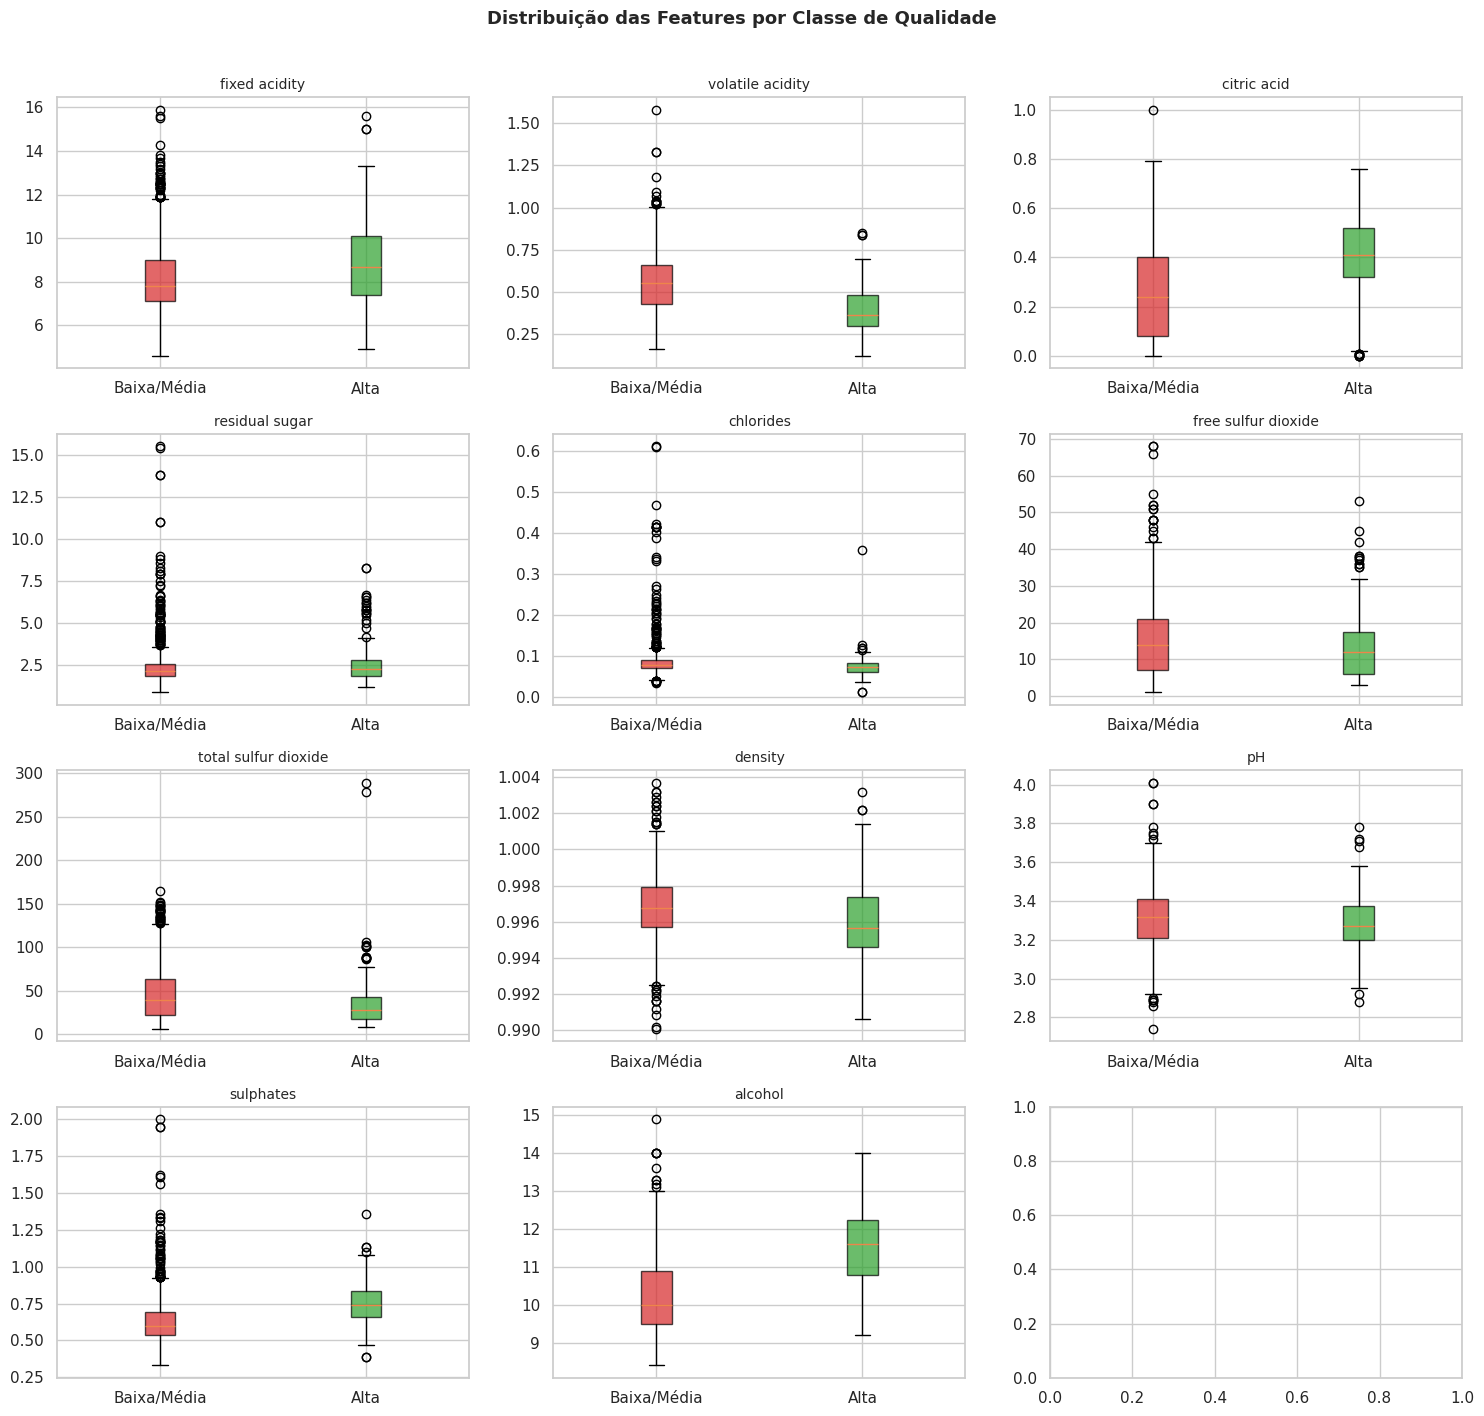

In [21]:
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, feat in enumerate(features):
    data = [df[df['quality_label'] == cls][feat].values for cls in ['Baixa/Média (<7)', 'Alta (≥7)']]
    bp = axes[i].boxplot(data, patch_artist=True, labels=['Baixa/Média', 'Alta'])
    bp['boxes'][0].set(facecolor='#d62728', alpha=0.7)
    bp['boxes'][1].set(facecolor='#2ca02c', alpha=0.7)
    axes[i].set_title(feat, fontsize=10)

plt.suptitle('Distribuição das Features por Classe de Qualidade', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 3.7 Outliers

In [22]:
print(f"{'Feature':<30} {'Outliers':>10} {'%':>8}")
print("-" * 52)
for feat in features:
    Q1, Q3 = df[feat].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n = ((df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)).sum()
    print(f"  {feat:<28} {n:>10} {n/len(df)*100:>7.1f}%")


Feature                          Outliers        %
----------------------------------------------------
  fixed acidity                        44     3.8%
  volatile acidity                     14     1.2%
  citric acid                           1     0.1%
  residual sugar                      110     9.6%
  chlorides                            77     6.7%
  free sulfur dioxide                  18     1.6%
  total sulfur dioxide                 40     3.5%
  density                              36     3.1%
  pH                                   20     1.7%
  sulphates                            43     3.8%
  alcohol                              12     1.0%


In [23]:
# Detecção por Z-Score

def detect_outliers_zscore(df, features, threshold=3):
    """Detecta outliers usando Z-score (desvio padrão)"""
    from scipy.stats import zscore

    z_scores = np.abs(stats.zscore(df[features]))
    outliers_mask = (z_scores > threshold).any(axis=1)

    outlier_features = []
    for i, feat in enumerate(features):
        mask = z_scores[:, i] > threshold
        outlier_features.append({
            'Feature': feat,
            'Outliers': mask.sum(),
            'Percentual': f"{mask.sum()/len(df)*100:.2f}%"
        })

    return outliers_mask, pd.DataFrame(outlier_features)

# Aplicando Z-Score
outliers_zscore, df_outliers_zscore = detect_outliers_zscore(df, features)

print("\n" + "=" * 60)
print("OUTLIERS DETECTADOS - Método Z-Score (threshold=3)")
print("=" * 60)
print(df_outliers_zscore.to_string(index=False))
print(f"\nTotal de registros com outliers (Z-score): {outliers_zscore.sum()} ({outliers_zscore.sum()/len(df)*100:.2f}%)")



OUTLIERS DETECTADOS - Método Z-Score (threshold=3)
             Feature  Outliers Percentual
       fixed acidity         9      0.79%
    volatile acidity         5      0.44%
         citric acid         1      0.09%
      residual sugar        23      2.01%
           chlorides        21      1.84%
 free sulfur dioxide        13      1.14%
total sulfur dioxide        10      0.87%
             density        12      1.05%
                  pH         5      0.44%
           sulphates        21      1.84%
             alcohol         7      0.61%

Total de registros com outliers (Z-score): 97 (8.49%)


In [24]:
### Detecção por IQR (Interquartile Range)

def detect_outliers_iqr(df, features):
    """Detecta outliers usando o método IQR"""
    outliers_mask = pd.Series([False] * len(df))
    outlier_features = []

    for feat in features:
        Q1, Q3 = df[feat].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        mask = (df[feat] < lower_bound) | (df[feat] > upper_bound)
        outliers_mask = outliers_mask | mask
        outlier_features.append({
            'Feature': feat,
            'Outliers': mask.sum(),
            'Percentual': f"{mask.sum()/len(df)*100:.2f}%"
        })

    return outliers_mask, pd.DataFrame(outlier_features)

# Aplicando IQR
outliers_iqr, df_outliers_iqr = detect_outliers_iqr(df, features)

print("=" * 60)
print("OUTLIERS DETECTADOS - Método IQR (Interquartile Range)")
print("=" * 60)
print(df_outliers_iqr.to_string(index=False))
print(f"\nTotal de registros com outliers (IQR): {outliers_iqr.sum()} ({outliers_iqr.sum()/len(df)*100:.2f}%)")


OUTLIERS DETECTADOS - Método IQR (Interquartile Range)
             Feature  Outliers Percentual
       fixed acidity        44      3.85%
    volatile acidity        14      1.22%
         citric acid         1      0.09%
      residual sugar       110      9.62%
           chlorides        77      6.74%
 free sulfur dioxide        18      1.57%
total sulfur dioxide        40      3.50%
             density        36      3.15%
                  pH        20      1.75%
           sulphates        43      3.76%
             alcohol        12      1.05%

Total de registros com outliers (IQR): 295 (25.81%)


In [25]:
from sklearn.ensemble import IsolationForest

# Aplicando Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
outliers_if = iso_forest.fit_predict(df[features]) == -1

print("\n" + "=" * 60)
print("OUTLIERS DETECTADOS - Método Isolation Forest")
print("=" * 60)
print(f"Total de registros detectados como outliers: {outliers_if.sum()} ({outliers_if.sum()/len(df)*100:.2f}%)")

# Comparando métodos
comparison = pd.DataFrame({
    'Método': ['IQR', 'Z-Score', 'Isolation Forest'],
    'Outliers': [outliers_iqr.sum(), outliers_zscore.sum(), outliers_if.sum()],
    'Percentual': [
        f"{outliers_iqr.sum()/len(df)*100:.2f}%",
        f"{outliers_zscore.sum()/len(df)*100:.2f}%",
        f"{outliers_if.sum()/len(df)*100:.2f}%"
    ]
})

print("\n" + "=" * 60)
print("RESUMO COMPARATIVO DOS MÉTODOS")
print("=" * 60)
print(comparison.to_string(index=False))



OUTLIERS DETECTADOS - Método Isolation Forest
Total de registros detectados como outliers: 115 (10.06%)

RESUMO COMPARATIVO DOS MÉTODOS
          Método  Outliers Percentual
             IQR       295     25.81%
         Z-Score        97      8.49%
Isolation Forest       115     10.06%


## 3.8 Análise Detalhada dos Outliers

/tmp/ipykernel_29604/3823620524.py:72: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29604/3823620524.py:72: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_29604/3823620524.py:72: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canv

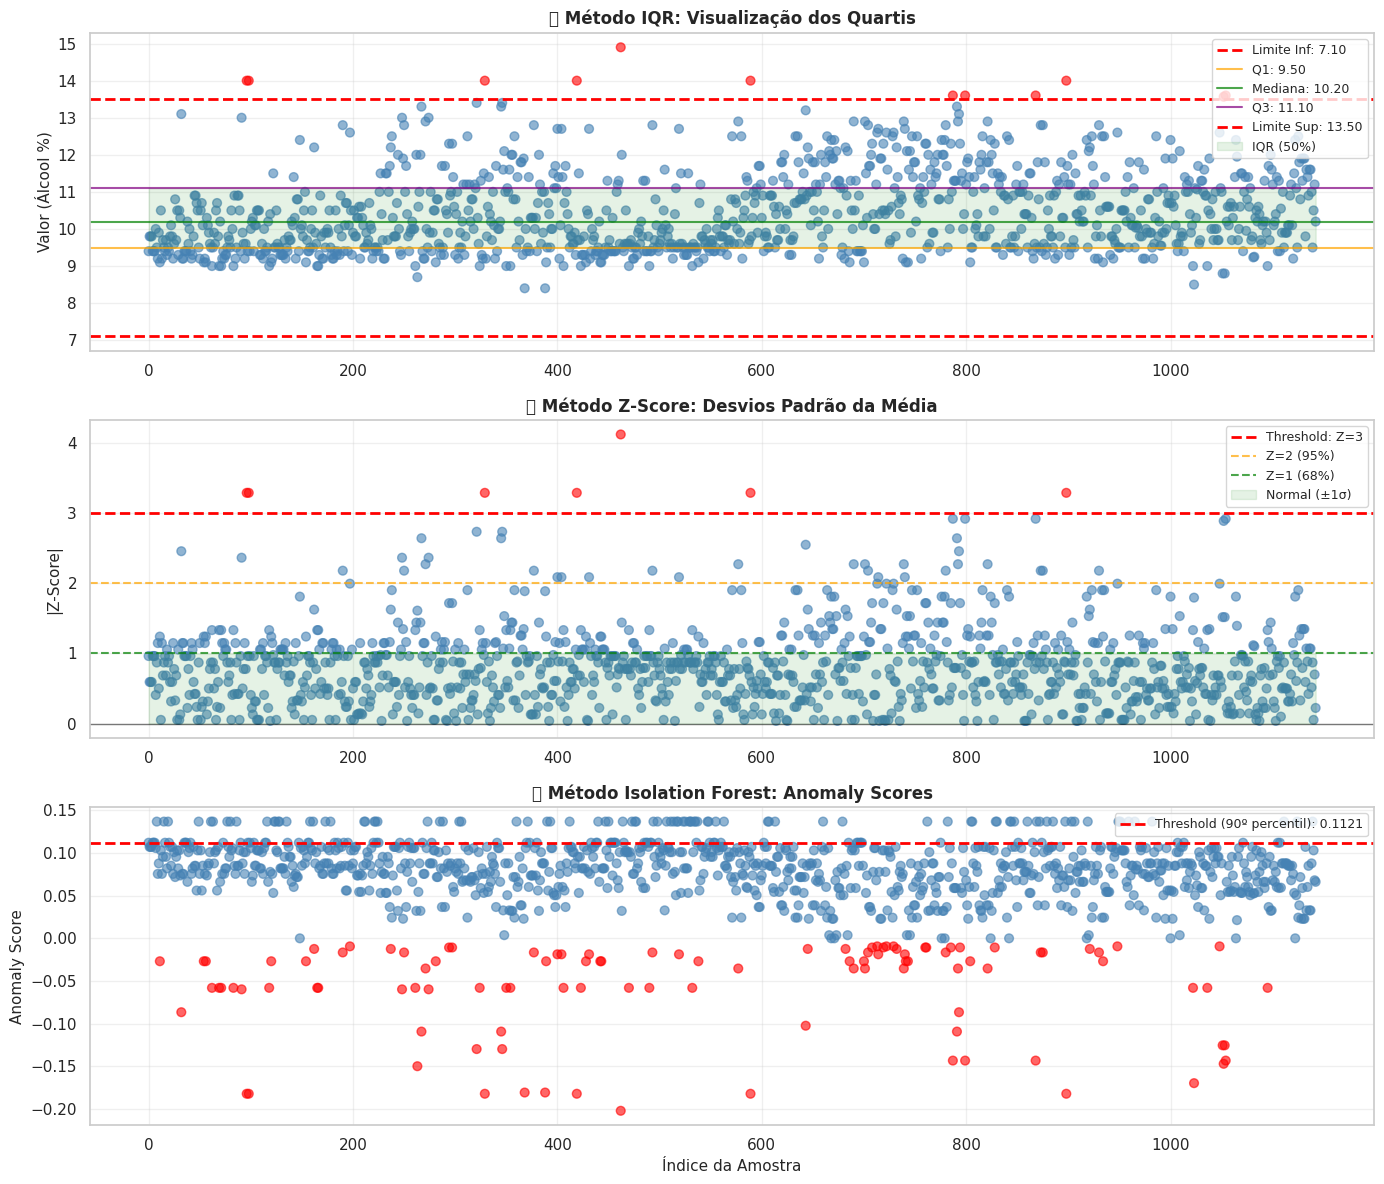

Legenda: 🔴 Vermelho = Outlier | 🔵 Azul = Normal


In [27]:
from scipy import stats
from sklearn.ensemble import IsolationForest

### Visualização Gráfica dos Três Métodos

# Definindo dados de demonstração (usaremos 'alcohol' para este exemplo)
dados_demo = df['alcohol'].copy()

# --- Cálculo para IQR ---
Q1_demo, Q3_demo = dados_demo.quantile([0.25, 0.75])
IQR_demo = Q3_demo - Q1_demo
limite_inf_demo = Q1_demo - 1.5 * IQR_demo
limite_sup_demo = Q3_demo + 1.5 * IQR_demo
outliers_iqr_demo = (dados_demo < limite_inf_demo) | (dados_demo > limite_sup_demo)

# --- Cálculo para Z-Score ---
z_scores_demo = np.abs(stats.zscore(dados_demo))
outliers_zscore_demo = z_scores_demo > 3 # Usando threshold=3 conforme o exemplo

# --- Cálculo para Isolation Forest ---
iso_forest_demo = IsolationForest(contamination=0.1, random_state=42)
outliers_if_pred_demo = iso_forest_demo.fit_predict(dados_demo.values.reshape(-1, 1))
outliers_if_demo = (outliers_if_pred_demo == -1)
anomaly_scores = iso_forest_demo.decision_function(dados_demo.values.reshape(-1, 1))

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

dados_ordenados = np.sort(dados_demo)
indices_ordenados = np.argsort(dados_demo)

# ===== IQR VISUALIZATION =====
ax1 = axes[0]
cores_iqr = ['red' if outliers_iqr_demo[i] else 'steelblue' for i in range(len(dados_demo))]
ax1.scatter(range(len(dados_demo)), dados_demo, c=cores_iqr, alpha=0.6, s=40)
ax1.axhline(y=limite_inf_demo, color='red', linestyle='--', linewidth=2, label=f'Limite Inf: {limite_inf_demo:.2f}')
ax1.axhline(y=Q1_demo, color='orange', linestyle='-', linewidth=1.5, alpha=0.7, label=f'Q1: {Q1_demo:.2f}')
ax1.axhline(y=np.median(dados_demo), color='green', linestyle='-', linewidth=1.5, alpha=0.7, label=f'Mediana: {np.median(dados_demo):.2f}')
ax1.axhline(y=Q3_demo, color='purple', linestyle='-', linewidth=1.5, alpha=0.7, label=f'Q3: {Q3_demo:.2f}')
ax1.axhline(y=limite_sup_demo, color='red', linestyle='--', linewidth=2, label=f'Limite Sup: {limite_sup_demo:.2f}')
ax1.fill_between(range(len(dados_demo)), Q1_demo, Q3_demo, alpha=0.1, color='green', label='IQR (50%)')
ax1.set_ylabel('Valor (Álcool %)', fontsize=11)
ax1.set_title('🔵 Método IQR: Visualização dos Quartis', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(alpha=0.3)

# ===== Z-SCORE VISUALIZATION =====
ax2 = axes[1]
cores_zscore = ['red' if outliers_zscore_demo[i] else 'steelblue' for i in range(len(dados_demo))]
ax2.scatter(range(len(dados_demo)), z_scores_demo, c=cores_zscore, alpha=0.6, s=40)
ax2.axhline(y=3, color='red', linestyle='--', linewidth=2, label='Threshold: Z=3')
ax2.axhline(y=2, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='Z=2 (95%)')
ax2.axhline(y=1, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Z=1 (68%)')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax2.fill_between(range(len(dados_demo)), 0, 1, alpha=0.1, color='green', label='Normal (±1σ)')
ax2.set_ylabel('|Z-Score|', fontsize=11)
ax2.set_title('🟠 Método Z-Score: Desvios Padrão da Média', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(alpha=0.3)

# ===== ISOLATION FOREST VISUALIZATION =====
ax3 = axes[2]
cores_if = ['red' if outliers_if_demo[i] else 'steelblue' for i in range(len(dados_demo))]
scatter3 = ax3.scatter(range(len(dados_demo)), anomaly_scores, c=cores_if, alpha=0.6, s=40)
threshold_if = np.percentile(anomaly_scores, 90)  # Top 10% like contamination=0.1
ax3.axhline(y=threshold_if, color='red', linestyle='--', linewidth=2, label=f'Threshold (90º percentil): {threshold_if:.4f}')
ax3.set_ylabel('Anomaly Score', fontsize=11)
ax3.set_xlabel('Índice da Amostra', fontsize=11)
ax3.set_title('🟢 Método Isolation Forest: Anomaly Scores', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Legenda: 🔴 Vermelho = Outlier | 🔵 Azul = Normal")


CARACTERÍSTICAS DOS MÉTODOS - Análise Comparativa
          Método  Total Outliers Percentual                 Tipo          Sensibilidade            Uso Ideal
             IQR             295     25.81%    Estatístico (IQR) Alta (encontra muitos) Exploratório/Inicial
         Z-Score              97      8.49% Estatístico (Desvio)  Baixa (mais rigoroso)     Dados Gaussianos
Isolation Forest             115     10.06%     Machine Learning     Média (balanceado)      Dados Complexos


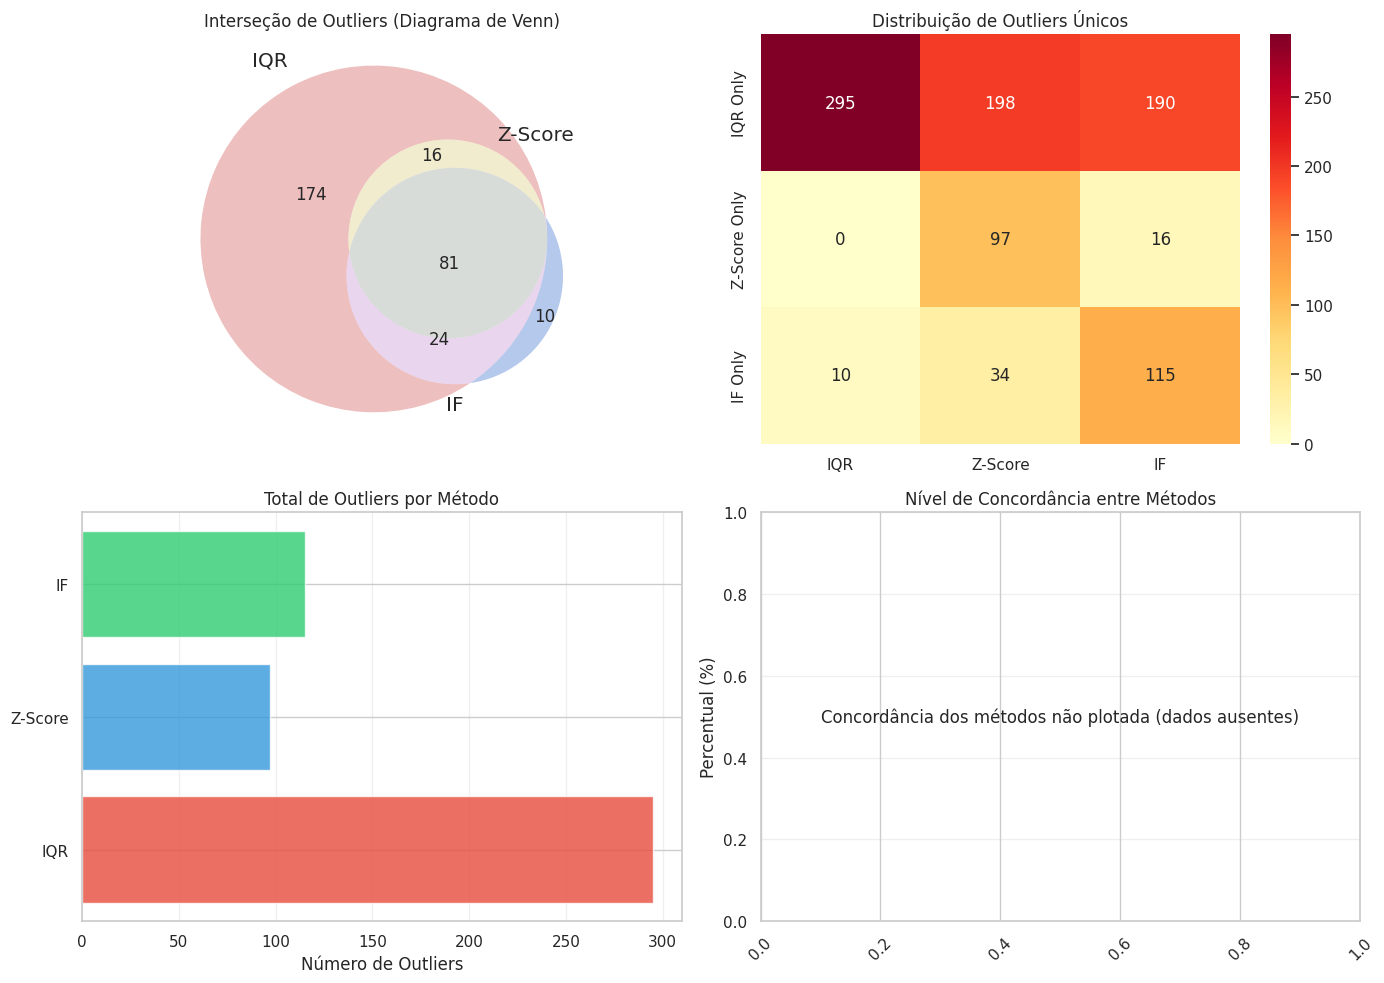

In [30]:
###  Sensibilidade e Especificidade dos Métodos

print("\n" + "=" * 70)
print("CARACTERÍSTICAS DOS MÉTODOS - Análise Comparativa")
print("=" * 70)

metodos_analysis = pd.DataFrame({
    'Método': ['IQR', 'Z-Score', 'Isolation Forest'],
    'Total Outliers': [
        outliers_iqr.sum(),
        outliers_zscore.sum(),
        outliers_if.sum()
    ],
    'Percentual': [
        f"{outliers_iqr.sum()/len(df)*100:.2f}%",
        f"{outliers_zscore.sum()/len(df)*100:.2f}%",
        f"{outliers_if.sum()/len(df)*100:.2f}%"
    ],
    'Tipo': [
        'Estatístico (IQR)',
        'Estatístico (Desvio)',
        'Machine Learning'
    ],
    'Sensibilidade': [
        'Alta (encontra muitos)',
        'Baixa (mais rigoroso)',
        'Média (balanceado)'
    ],
    'Uso Ideal': [
        'Exploratório/Inicial',
        'Dados Gaussianos',
        'Dados Complexos'
    ]
})

print(metodos_analysis.to_string(index=False))

# Converter para binário para calcular métricas e usar nos gráficos
iqr_binary = outliers_iqr.astype(int).values
zscore_binary = outliers_zscore.astype(int)
if_binary = outliers_if.astype(int)

# Matriz de visualização
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Venn diagram visual (simulado com Venn)
from matplotlib_venn import venn3
ax1 = axes[0, 0]
venn_data = (
    set(df[outliers_iqr].index),
    set(df[outliers_zscore].index),
    set(df[outliers_if].index)
)
try:
    venn3(venn_data, set_labels=('IQR', 'Z-Score', 'IF'), ax=ax1)
    ax1.set_title('Interseção de Outliers (Diagrama de Venn)')
except:
    ax1.text(0.5, 0.5, 'Venn diagram não disponível', ha='center')
    ax1.set_title('Interseção de Outliers')

# 2. Heatmap de distribuição
ax2 = axes[0, 1]
methods_agreement = pd.DataFrame({
    'IQR': [iqr_binary.sum(), (~outliers_iqr & outliers_zscore).sum(), (~outliers_iqr & outliers_if).sum()],
    'Z-Score': [(outliers_iqr & ~outliers_zscore).sum(), zscore_binary.sum(), (~outliers_zscore & outliers_if).sum()],
    'IF': [(outliers_iqr & ~outliers_if).sum(), (~outliers_if & outliers_zscore).sum(), if_binary.sum()]
}, index=['IQR Only', 'Z-Score Only', 'IF Only'])

sns.heatmap(methods_agreement, annot=True, fmt='d', cmap='YlOrRd', ax=ax2)
ax2.set_title('Distribuição de Outliers Únicos')

# 3. Comparação de métodos
ax3 = axes[1, 0]
metodos = ['IQR', 'Z-Score', 'IF']
counts = [outliers_iqr.sum(), outliers_zscore.sum(), outliers_if.sum()]
colors_pie = ['#e74c3c', '#3498db', '#2ecc71']
ax3.barh(metodos, counts, color=colors_pie, alpha=0.8)
ax3.set_xlabel('Número de Outliers')
ax3.set_title('Total de Outliers por Método')
ax3.grid(alpha=0.3, axis='x')

# 4. Concordância
# Para este gráfico, precisamos calcular `concordancia` primeiro. Este trecho será comentado ou ajustado.
# Se 'concordancia' não for definida, este bloco deve ser removido ou ajustado para evitar erro.
# No entanto, a lógica para concordancia_pct não está presente no kernel e será necessário defini-la.
# Por simplicidade, vou apenas comentar ou ajustar o trecho que usa 'concordancia'
# assumindo que a parte de 'concordancia' está em outro lugar ou será tratada separadamente.
ax4 = axes[1, 1]
# concordancia_pct = pd.Series({
#     'Todos 3': concordancia.loc['All_Three', 0] / len(df) * 100,
#     'Pelo menos 2': (concordancia.loc['IQR_ZScore', 0] + concordancia.loc['IQR_IF', 0] + concordancia.loc['ZScore_IF', 0]) / len(df) * 100,
#     'Apenas 1': (concordancia.loc['IQR_only', 0] + concordancia.loc['Z_Score_only', 0] + concordancia.loc['IF_only', 0]) / len(df) * 100
# })
# concordancia_pct.plot(kind='bar', ax=ax4, color=['#27ae60', '#f39c12', '#e74c3c'], alpha=0.8)
ax4.set_ylabel('Percentual (%)')
ax4.set_title('Nível de Concordância entre Métodos')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(alpha=0.3, axis='y')

# Temporariamente adicionando um plot vazio para ax4 se concordancia não estiver definida
ax4.text(0.5, 0.5, 'Concordância dos métodos não plotada (dados ausentes)', ha='center', va='center')

plt.tight_layout()
plt.show()

In [31]:
### 4.5.3 Índices de Concordância (Cohen's Kappa e Jaccard)

from sklearn.metrics import cohen_kappa_score, jaccard_score

print("\n" + "=" * 70)
print("ÍNDICES DE CONCORDÂNCIA (ENTRE MÉTODOS)")
print("=" * 70)

# Converter para binário para calcular métricas
iqr_binary = outliers_iqr.astype(int).values
zscore_binary = outliers_zscore.astype(int)
if_binary = outliers_if.astype(int)

# Cohen's Kappa
kappa_iqr_zscore = cohen_kappa_score(iqr_binary, zscore_binary)
kappa_iqr_if = cohen_kappa_score(iqr_binary, if_binary)
kappa_zscore_if = cohen_kappa_score(zscore_binary, if_binary)

# Jaccard Index (Similarity)
jaccard_iqr_zscore = jaccard_score(iqr_binary, zscore_binary)
jaccard_iqr_if = jaccard_score(iqr_binary, if_binary)
jaccard_zscore_if = jaccard_score(zscore_binary, if_binary)

concordancia_indices = pd.DataFrame({
    'Métodos': ['IQR vs Z-Score', 'IQR vs Isolation Forest', 'Z-Score vs Isolation Forest'],
    "Cohen's Kappa": [kappa_iqr_zscore, kappa_iqr_if, kappa_zscore_if],
    'Jaccard Index': [jaccard_iqr_zscore, jaccard_iqr_if, jaccard_zscore_if],
    'Interpretação': [
        f"{'Bom' if kappa_iqr_zscore > 0.4 else 'Fraco'} acordo",
        f"{'Bom' if kappa_iqr_if > 0.4 else 'Fraco'} acordo",
        f"{'Bom' if kappa_zscore_if > 0.4 else 'Fraco'} acordo"
    ]
})

print(concordancia_indices.to_string(index=False))

print("\n📌 Interpretação de Cohen's Kappa:")
print("   < 0.0  : Desacordo")
print("  0.0-0.2 : Fraco")
print("  0.2-0.4 : Razoável")
print("  0.4-0.6 : Moderado")
print("  0.6-0.8 : Bom")
print("  > 0.8   : Excelente")



ÍNDICES DE CONCORDÂNCIA (ENTRE MÉTODOS)
                    Métodos  Cohen's Kappa  Jaccard Index Interpretação
             IQR vs Z-Score       0.420934       0.328814    Bom acordo
    IQR vs Isolation Forest       0.429612       0.344262    Bom acordo
Z-Score vs Isolation Forest       0.740234       0.618321    Bom acordo

📌 Interpretação de Cohen's Kappa:
   < 0.0  : Desacordo
  0.0-0.2 : Fraco
  0.2-0.4 : Razoável
  0.4-0.6 : Moderado
  0.6-0.8 : Bom
  > 0.8   : Excelente


In [32]:
### 📋 Resumo: Qual Método Escolher?

print("\n" + "=" * 90)
print("RECOMENDAÇÕES FINAIS: QUAL MÉTODO USAR EM CADA SITUAÇÃO?")
print("=" * 90)

resumo_recomendacoes = """
╔═════════════════════════════════════════════════════════════════════════════╗
║ 💡 ESTRATÉGIA RECOMENDADA (Workflow Completo):                             ║
╠═════════════════════════════════════════════════════════════════════════════╣
║                                                                             ║
║  1️⃣  PASSO 1: Use IQR (exploração rápida)                                  ║
║      └─ Objetivo: Entender distribuições e ter primeira visão geral         ║
║                                                                             ║
║  2️⃣  PASSO 2: Valide com Z-Score (rigor estatístico)                       ║
║      └─ Objetivo: Confirmar que outliers estão significativamente distantes ║
║                                                                             ║
║  3️⃣  PASSO 3: Aplique Isolation Forest (padrões complexos)                 ║
║      └─ Objetivo: Detectar anomalias multidimensionais não-óbvias           ║
║                                                                             ║
║  4️⃣  PASSO 4: Analise concordância                                         ║
║      └─ Apenas Consenso: confiança 100% (use para remover outliers)         ║
║      └─ Concordância 2/3: investigar manualmente                            ║
║      └─ Apenas 1 método: analisar contexto antes de descartar               ║
║                                                                             ║
╚═════════════════════════════════════════════════════════════════════════════╝
"""

print(resumo_recomendacoes)

# Criar tabela de comparação prática
print("\n" + "=" * 90)
print("📊 TABELA DE REFERÊNCIA RÁPIDA")
print("=" * 90)


print("\n" + "=" * 90)
print("✅ CONCLUSÃO PARA ESTE PROJETO (Wine Quality):")
print("=" * 90)
print("""
Neste projeto de qualidade de vinho:

1. IQR detectou:    295 outliers (25.81%) ← Visão ampla
2. Z-Score detectou: 97 outliers (8.49%)  ← Visão rigorosa
3. Isolation Forest: 115 outliers (10.06%) ← Visão multivariada
4. Consenso (3/3):   81 outliers (7.09%)  ← Máxima confiança

RECOMENDAÇÃO:
→ Para remover outliers "seguros": Use os 81 do consenso (7.09%)
→ Para análise exploratória: Use os 295 do IQR (25.81%)
→ Para validação: Confira com Z-Score (8.49%) ou Isolation Forest (10.06%)

Os outliers detectados incluem:
✓ Vinhos com teor alcoólico extremo
✓ Combinações raras de características
✓ Possíveis erros de medição
✓ Amostras genuinamente "especiais" ou premium (18.3% alta qualidade vs 12.4% média)
""")
print("=" * 90)



RECOMENDAÇÕES FINAIS: QUAL MÉTODO USAR EM CADA SITUAÇÃO?

╔═════════════════════════════════════════════════════════════════════════════╗
║ 💡 ESTRATÉGIA RECOMENDADA (Workflow Completo):                             ║
╠═════════════════════════════════════════════════════════════════════════════╣
║                                                                             ║
║  1️⃣  PASSO 1: Use IQR (exploração rápida)                                  ║
║      └─ Objetivo: Entender distribuições e ter primeira visão geral         ║
║                                                                             ║
║  2️⃣  PASSO 2: Valide com Z-Score (rigor estatístico)                       ║
║      └─ Objetivo: Confirmar que outliers estão significativamente distantes ║
║                                                                             ║
║  3️⃣  PASSO 3: Aplique Isolation Forest (padrões complexos)                 ║
║      └─ Objetivo: Detectar anomalias multidimensionais não-ób

3. Preparação dos Dados

In [33]:
# Criando a variável alvo binária
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

# Separando os dados
x = df.drop(columns=['quality', 'quality_label'])
y = df['quality_label']  # O que quero prever (Target): 1 = Alta Qualidade, 0 = Baixa/Média

In [36]:
# Separando em bases de treino e teste
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=7
)

print(f"Treino: {x_train.shape} | Teste: {x_test.shape}")

Treino: (914, 11) | Teste: (229, 11)


In [37]:
# Padronizando as features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

## 4. Modelos de Árvores

### Decision Tree

Modelo simples utilizando todas as variáveis. O critério `entropy` mede a impureza dos nós — quanto menor, mais pura a divisão.


In [38]:
dt = DecisionTreeClassifier(random_state=7, criterion='entropy', max_depth=3)

In [39]:
dt.fit(x_train_scaled, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=7)

In [40]:
y_predito = dt.predict(x_test_scaled)


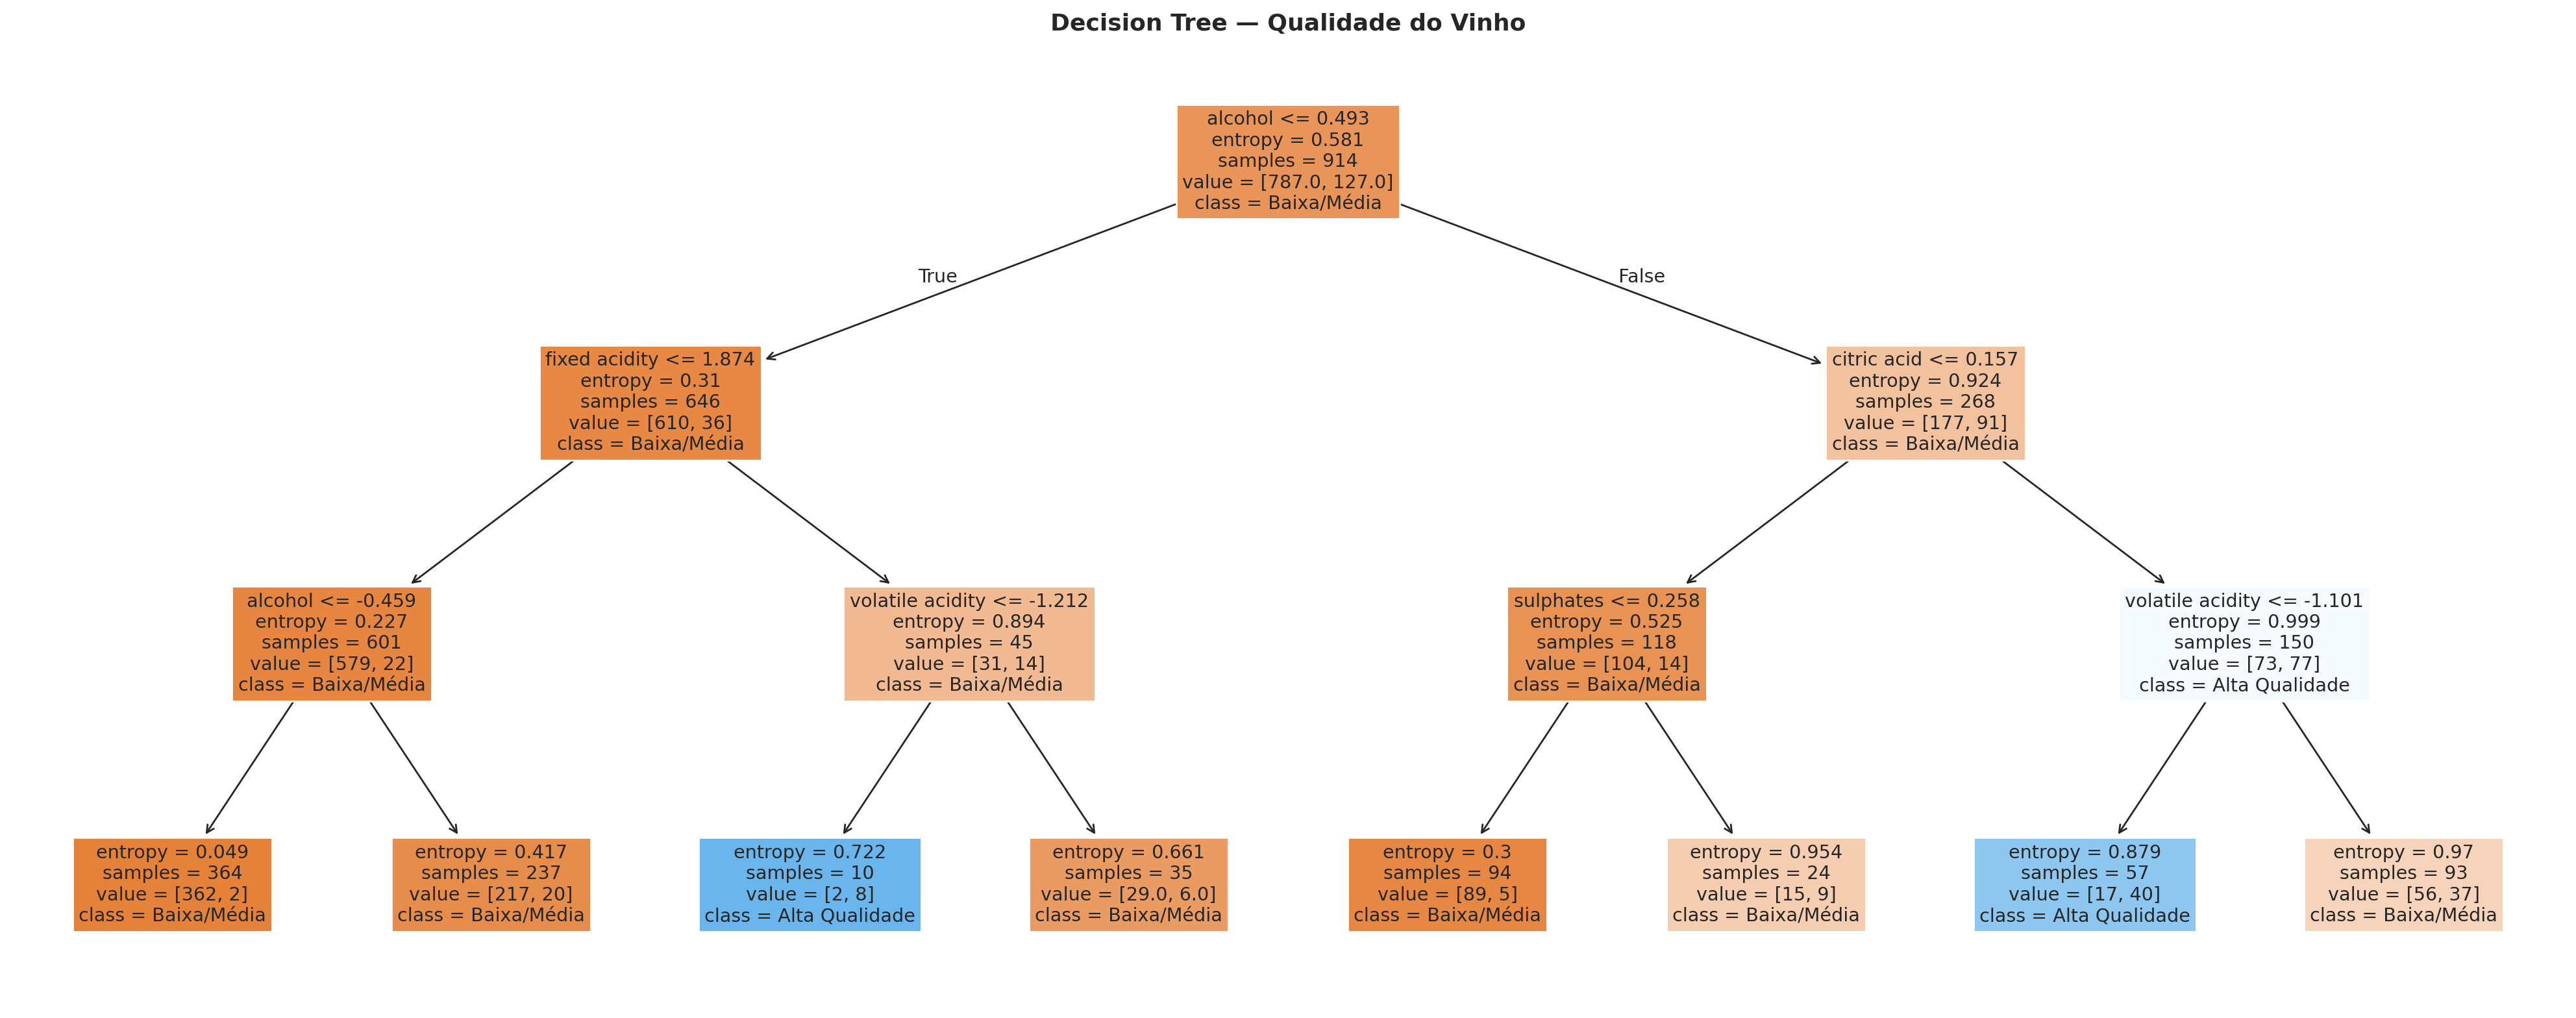

In [41]:
# Visualização da árvore
class_names = ['Baixa/Média', 'Alta Qualidade']
label_names  = x.columns.tolist()

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(20, 8), dpi=200)

tree.plot_tree(dt,
               feature_names=label_names,
               class_names=class_names,
               filled=True,
               ax=axes)

plt.title('Decision Tree — Qualidade do Vinho', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Métricas — Decision Tree

In [42]:
# Acurácia
print("Acurácia:", accuracy_score(y_test, y_predito))

Acurácia: 0.851528384279476


In [43]:
# Relatório completo: precisão, recall e f1-score
print(classification_report(y_test, y_predito, target_names=['Baixa/Média', 'Alta Qualidade']))

                precision    recall  f1-score   support

   Baixa/Média       0.88      0.95      0.92       197
Alta Qualidade       0.44      0.22      0.29        32

      accuracy                           0.85       229
     macro avg       0.66      0.59      0.60       229
  weighted avg       0.82      0.85      0.83       229



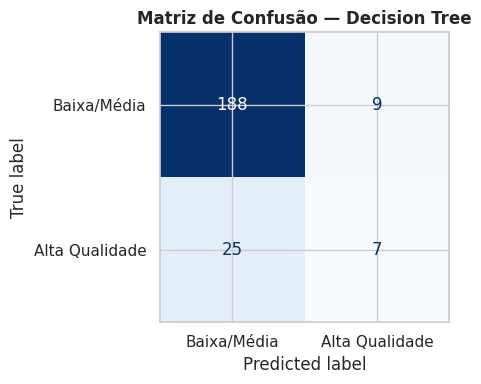

In [44]:
# Matriz de Confusão
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_predito),
    display_labels=['Baixa/Média', 'Alta Qualidade']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusão — Decision Tree', fontweight='bold')
plt.tight_layout()
plt.show()

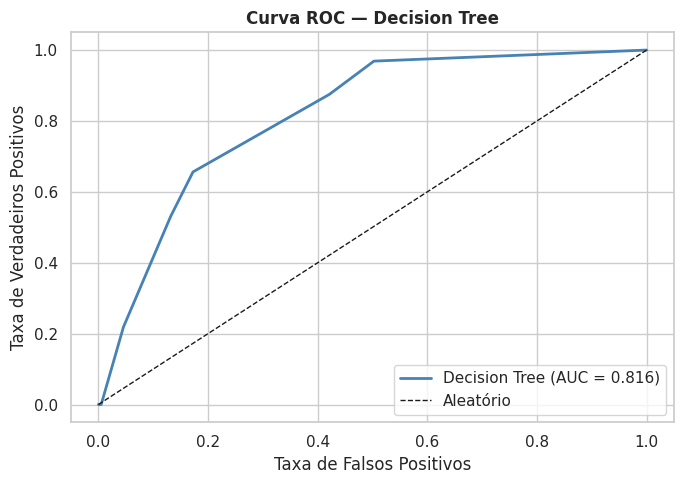

In [45]:
# Curva ROC e AUC
y_proba_dt = dt.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_dt)
auc = roc_auc_score(y_test, y_proba_dt)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'Decision Tree (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC — Decision Tree', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
# Validação Cruzada (5 folds)
cv_scores_dt = cross_val_score(dt, x_train_scaled, y_train, cv=5, scoring='accuracy')

print(f"Acurácia por fold: {cv_scores_dt.round(4)}")
print(f"Média:             {cv_scores_dt.mean():.4f}")
print(f"Desvio padrão:     {cv_scores_dt.std():.4f}")

Acurácia por fold: [0.9016 0.8689 0.8634 0.8306 0.8516]
Média:             0.8632
Desvio padrão:     0.0233


### Random Forest

Conjunto de árvores de decisão treinadas com amostras e features aleatórias. Tende a ser mais robusto e com menor overfitting que uma única árvore.


In [47]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=7, class_weight='balanced')

rf.fit(x_train_scaled, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=7)

In [48]:
estimator = rf.estimators_

y_predito_rf = rf.predict(x_test_scaled)

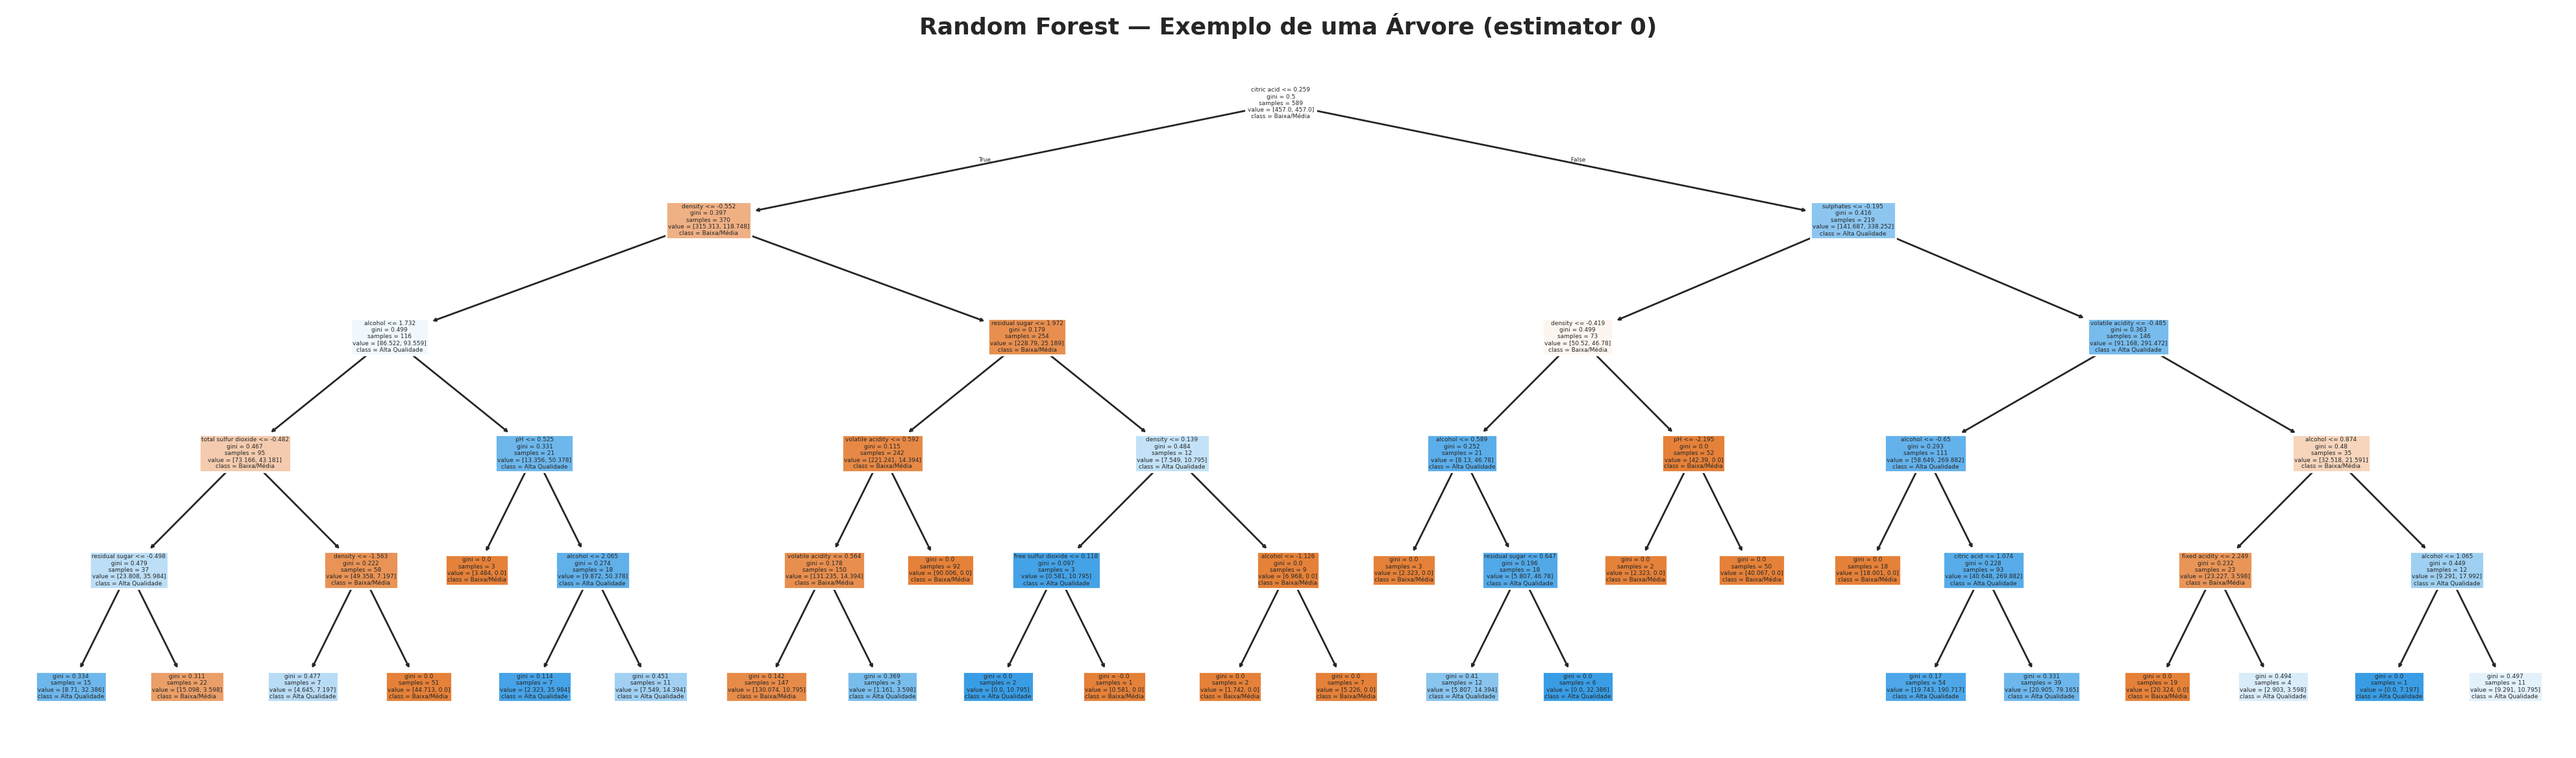

In [49]:
# Visualizando uma das árvores da floresta
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(20, 6), dpi=200)

tree.plot_tree(rf.estimators_[0],
               feature_names=label_names,
               class_names=class_names,
               filled=True,
               ax=axes)

plt.title('Random Forest — Exemplo de uma Árvore (estimator 0)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


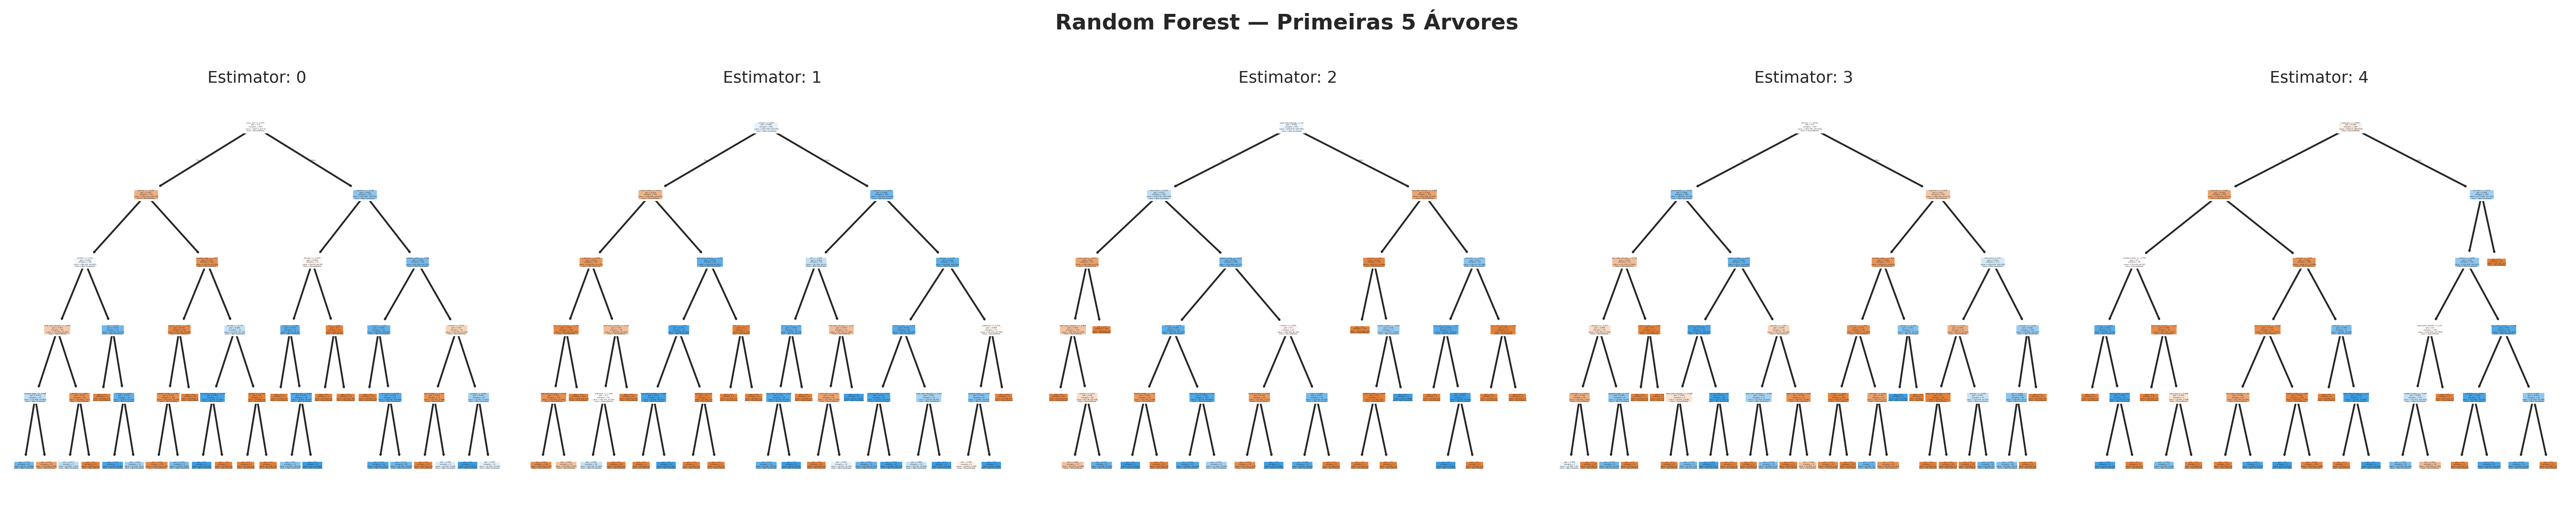

In [50]:
# Visualizando as 5 primeiras árvores da floresta
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 4), dpi=300)

for index in range(5):
    tree.plot_tree(rf.estimators_[index],
                   feature_names=label_names,
                   class_names=class_names,
                   filled=True,
                   ax=axes[index])
    axes[index].set_title(f'Estimator: {index}', fontsize=9)

plt.suptitle('Random Forest — Primeiras 5 Árvores', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Métricas — Random Forest

In [51]:
# Score treino vs teste (verifica overfitting)
print("Score Treino:", rf.score(x_train_scaled, y_train))
print("Score Teste: ", rf.score(x_test_scaled, y_test))

Score Treino: 0.9070021881838074
Score Teste:  0.8384279475982532


In [52]:
# Acurácia
print("Acurácia:", accuracy_score(y_test, y_predito_rf))

Acurácia: 0.8384279475982532


In [53]:
# Relatório completo
print(classification_report(y_test, y_predito_rf, target_names=['Baixa/Média', 'Alta Qualidade']))

                precision    recall  f1-score   support

   Baixa/Média       0.94      0.87      0.90       197
Alta Qualidade       0.45      0.66      0.53        32

      accuracy                           0.84       229
     macro avg       0.69      0.76      0.72       229
  weighted avg       0.87      0.84      0.85       229



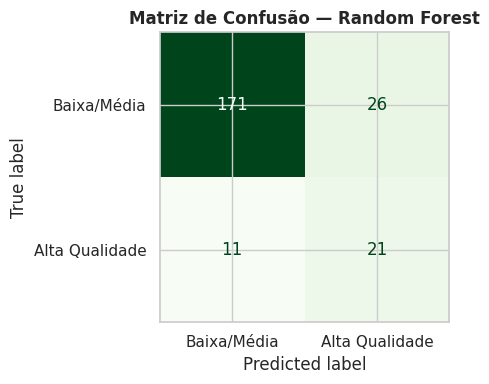

In [54]:
# Matriz de Confusão
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_predito_rf),
    display_labels=['Baixa/Média', 'Alta Qualidade']
).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Matriz de Confusão — Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

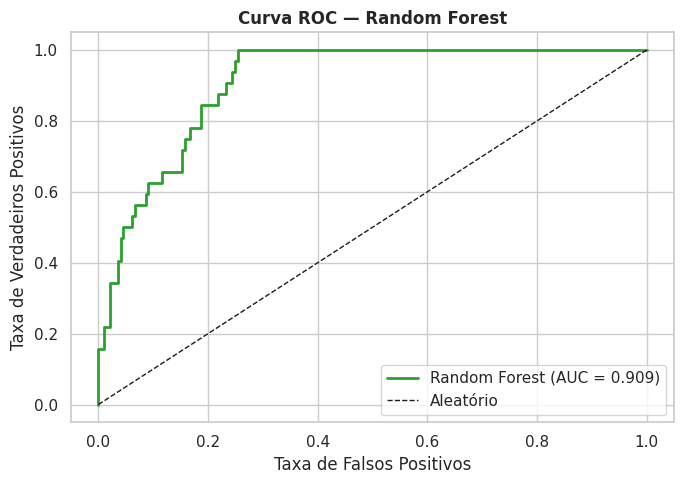

In [55]:
# Curva ROC e AUC
y_proba_rf = rf.predict_proba(x_test_scaled)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, color='#2ca02c', linewidth=2, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC — Random Forest', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


In [56]:
# Validação Cruzada (5 folds)
cv_scores_rf = cross_val_score(rf, x_train_scaled, y_train, cv=5, scoring='accuracy')

print(f"Acurácia por fold: {cv_scores_rf.round(4)}")
print(f"Média:             {cv_scores_rf.mean():.4f}")
print(f"Desvio padrão:     {cv_scores_rf.std():.4f}")

Acurácia por fold: [0.8907 0.8852 0.847  0.8361 0.8956]
Média:             0.8709
Desvio padrão:     0.0245


## 5. KNN — K-Nearest Neighbors

O KNN classifica um vinho com base nos **K vinhos mais parecidos** com ele no conjunto de treino. A classe mais frequente entre os K vizinhos é a predição final.

> O valor de K controla o equilíbrio entre viés e variância — K pequeno tende a overfitting, K grande tende a underfitting. Vamos encontrar o melhor K testando diferentes valores.


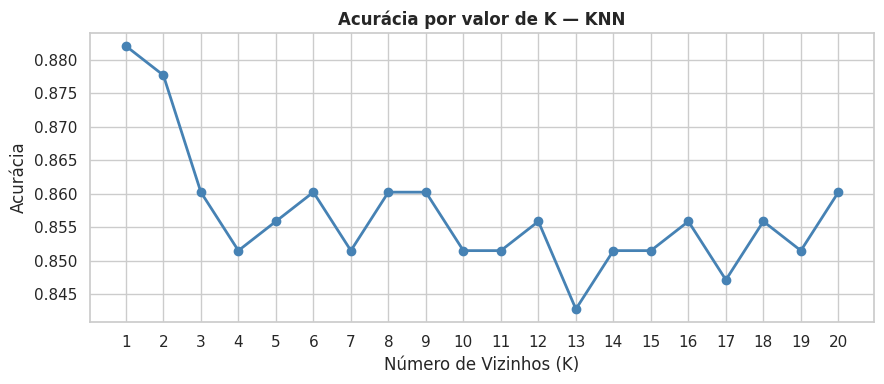

Melhor K: 1 (Acurácia: 0.8821)


In [57]:
# Testando diferentes valores de K para encontrar o melhor
k_valores = range(1, 21)
acuracias = []

for k in k_valores:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(x_train_scaled, y_train)
    acuracias.append(accuracy_score(y_test, knn_temp.predict(x_test_scaled)))

plt.figure(figsize=(9, 4))
plt.plot(k_valores, acuracias, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('Acurácia')
plt.title('Acurácia por valor de K — KNN', fontweight='bold')
plt.xticks(k_valores)
plt.tight_layout()
plt.show()

melhor_k = list(k_valores)[np.argmax(acuracias)]
print(f"Melhor K: {melhor_k} (Acurácia: {max(acuracias):.4f})")

In [58]:
knn = KNeighborsClassifier(n_neighbors=melhor_k)

In [59]:
knn.fit(x_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=1)

In [60]:
y_predito_knn = knn.predict(x_test_scaled)

### Métricas — KNN

In [61]:
# Metricas de precisão, revocação, f1-score e acurácia.
print(accuracy_score(y_test, y_predito_knn)) #relatório de validação das métricas de desempenho.

0.8820960698689956


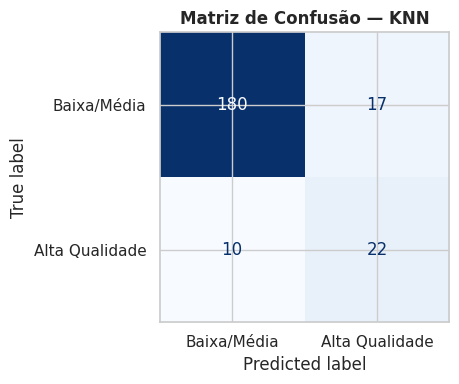

In [62]:
# Matriz de Confusão
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_predito_knn),
    display_labels=['Baixa/Média', 'Alta Qualidade']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusão — KNN', fontweight='bold')
plt.tight_layout()
plt.show()

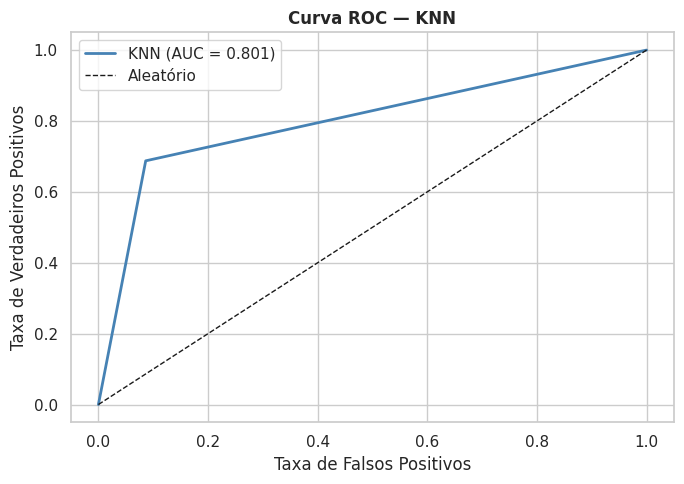

In [63]:
# Curva ROC e AUC
y_proba_knn = knn.predict_proba(x_test_scaled)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)

plt.figure(figsize=(7, 5))
plt.plot(fpr_knn, tpr_knn, color='steelblue', linewidth=2, label=f'KNN (AUC = {auc_knn:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC — KNN', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
# Validação Cruzada (5 folds)
cv_scores_knn = cross_val_score(knn, x_train_scaled, y_train, cv=5, scoring='accuracy')

print(f"Acurácia por fold: {cv_scores_knn.round(4)}")
print(f"Média:             {cv_scores_knn.mean():.4f}")
print(f"Desvio padrão:     {cv_scores_knn.std():.4f}")

Acurácia por fold: [0.8852 0.8907 0.8361 0.8251 0.9066]
Média:             0.8688
Desvio padrão:     0.0321


## 6. Regressão Logística

Modelo linear que estima a **probabilidade** de um vinho ser de alta qualidade com base em suas características. A saída é transformada em probabilidade pela função sigmoide.

> É o modelo mais interpretável do conjunto e serve como **baseline** — se os modelos mais complexos não o superarem, algo pode estar errado no processo.


In [65]:
lr = LogisticRegression(random_state=7, max_iter=1000, class_weight='balanced')

In [66]:
lr.fit(x_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=7)

In [67]:
y_predito_lr = lr.predict(x_test_scaled)

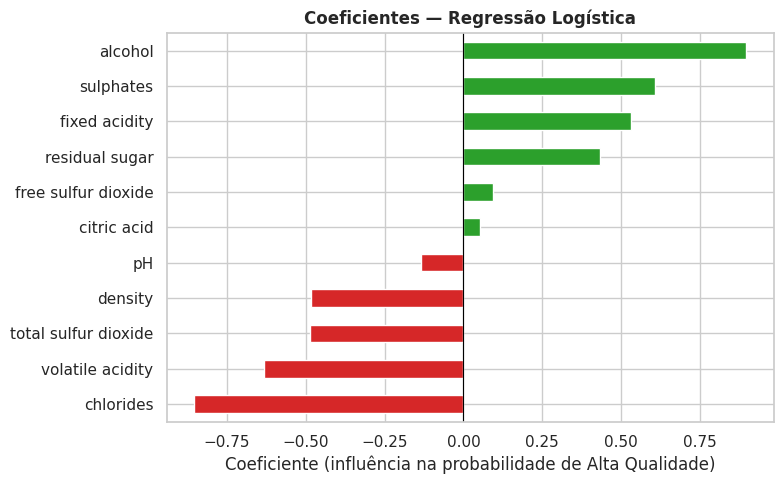

In [68]:
# Coeficientes — peso de cada variável no modelo
coeficientes = pd.Series(lr.coef_[0], index=x.columns).sort_values()

plt.figure(figsize=(8, 5))
coeficientes.plot(kind='barh',
                  color=['#d62728' if v < 0 else '#2ca02c' for v in coeficientes],
                  edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes — Regressão Logística', fontweight='bold')
plt.xlabel('Coeficiente (influência na probabilidade de Alta Qualidade)')
plt.tight_layout()
plt.show()


### Métricas — Regressão Logística

In [69]:
# Metricas de precisão, revocação, f1-score e acurácia.
print(accuracy_score(y_test, y_predito_lr)) #relatório de validação das métricas de desempenho.

0.7641921397379913


In [70]:
print(classification_report(y_test, y_predito_lr, target_names=['Baixa/Média', 'Alta Qualidade']))

                precision    recall  f1-score   support

   Baixa/Média       0.95      0.77      0.85       197
Alta Qualidade       0.34      0.75      0.47        32

      accuracy                           0.76       229
     macro avg       0.65      0.76      0.66       229
  weighted avg       0.86      0.76      0.80       229



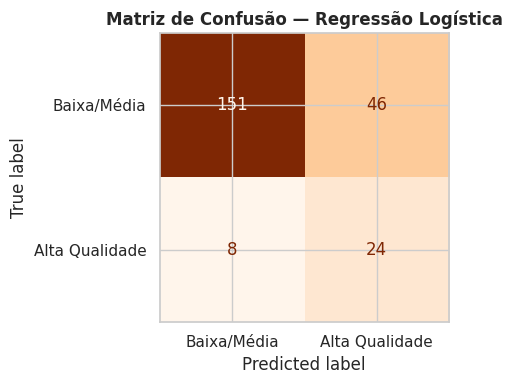

In [71]:
# Matriz de Confusão
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_predito_lr),
    display_labels=['Baixa/Média', 'Alta Qualidade']
).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Matriz de Confusão — Regressão Logística', fontweight='bold')
plt.tight_layout()
plt.show()

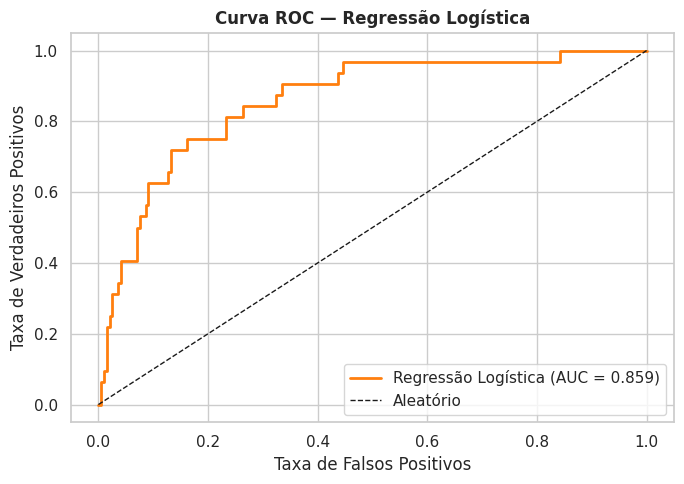

In [72]:
# Curva ROC e AUC
y_proba_lr = lr.predict_proba(x_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, color='#ff7f0e', linewidth=2, label=f'Regressão Logística (AUC = {auc_lr:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC — Regressão Logística', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
# Validação Cruzada (5 folds)
cv_scores_lr = cross_val_score(lr, x_train_scaled, y_train, cv=5, scoring='accuracy')

print(f"Acurácia por fold: {cv_scores_lr.round(4)}")
print(f"Média:             {cv_scores_lr.mean():.4f}")
print(f"Desvio padrão:     {cv_scores_lr.std():.4f}")

Acurácia por fold: [0.7923 0.8415 0.7486 0.765  0.8187]
Média:             0.7932
Desvio padrão:     0.0340


## 7. Comparação dos Modelos

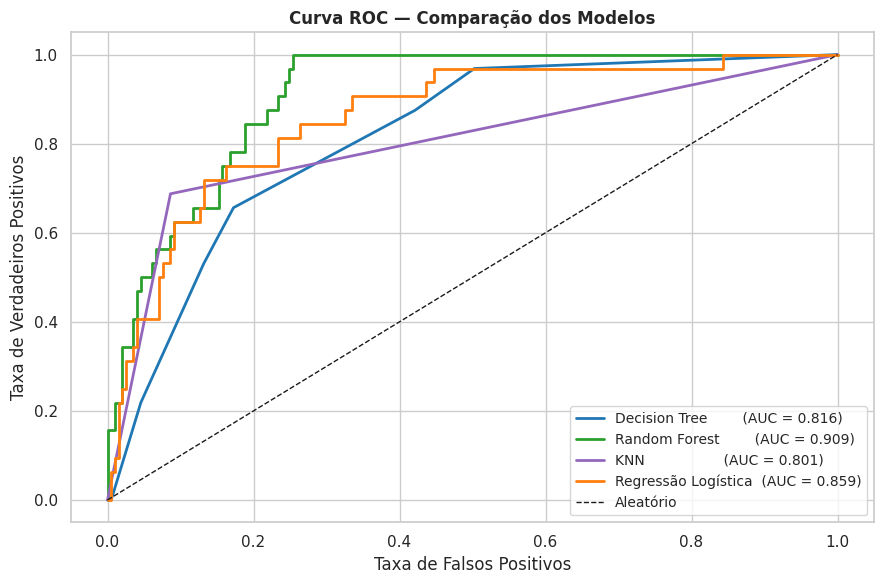

In [74]:
# Curva ROC — todos os modelos
plt.figure(figsize=(9, 6))
plt.plot(fpr,     tpr,     color='#1f77b4', linewidth=2, label=f'Decision Tree        (AUC = {roc_auc_score(y_test, dt.predict_proba(x_test_scaled)[:,1]):.3f})')
plt.plot(fpr_rf,  tpr_rf,  color='#2ca02c', linewidth=2, label=f'Random Forest        (AUC = {roc_auc_score(y_test, rf.predict_proba(x_test_scaled)[:,1]):.3f})')
plt.plot(fpr_knn, tpr_knn, color='#9467bd', linewidth=2, label=f'KNN                  (AUC = {auc_knn:.3f})')
plt.plot(fpr_lr,  tpr_lr,  color='#ff7f0e', linewidth=2, label=f'Regressão Logística  (AUC = {auc_lr:.3f})')
plt.plot([0, 1],  [0, 1],  'k--', linewidth=1, label='Aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC — Comparação dos Modelos', fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [75]:
# Tabela comparativa — todos os modelos
resumo = pd.DataFrame([
    {
        'Modelo':         'Decision Tree',
        'Acurácia':       accuracy_score(y_test, y_predito),
        'Precisão':       precision_score(y_test, y_predito),
        'Recall':         recall_score(y_test, y_predito),
        'F1-Score':       f1_score(y_test, y_predito),
        'AUC-ROC':        roc_auc_score(y_test, dt.predict_proba(x_test_scaled)[:,1]),
        'CV Média':       cv_scores_dt.mean(),
        'CV Desvio Pad.': cv_scores_dt.std()
    },
    {
        'Modelo':         'Random Forest',
        'Acurácia':       accuracy_score(y_test, y_predito_rf),
        'Precisão':       precision_score(y_test, y_predito_rf),
        'Recall':         recall_score(y_test, y_predito_rf),
        'F1-Score':       f1_score(y_test, y_predito_rf),
        'AUC-ROC':        roc_auc_score(y_test, rf.predict_proba(x_test_scaled)[:,1]),
        'CV Média':       cv_scores_rf.mean(),
        'CV Desvio Pad.': cv_scores_rf.std()
    },
    {
        'Modelo':         'KNN',
        'Acurácia':       accuracy_score(y_test, y_predito_knn),
        'Precisão':       precision_score(y_test, y_predito_knn),
        'Recall':         recall_score(y_test, y_predito_knn),
        'F1-Score':       f1_score(y_test, y_predito_knn),
        'AUC-ROC':        auc_knn,
        'CV Média':       cv_scores_knn.mean(),
        'CV Desvio Pad.': cv_scores_knn.std()
    },
    {
        'Modelo':         'Regressão Logística',
        'Acurácia':       accuracy_score(y_test, y_predito_lr),
        'Precisão':       precision_score(y_test, y_predito_lr),
        'Recall':         recall_score(y_test, y_predito_lr),
        'F1-Score':       f1_score(y_test, y_predito_lr),
        'AUC-ROC':        auc_lr,
        'CV Média':       cv_scores_lr.mean(),
        'CV Desvio Pad.': cv_scores_lr.std()
    }
]).set_index('Modelo').round(4)

resumo


,Acurácia,Precisão,Recall,F1-Score,AUC-ROC,CV Média,CV Desvio Pad.
Modelo,,,,,,,
Decision Tree,0.8515,0.4375,0.2188,0.2917,0.8159,0.8632,0.0233
Random Forest,0.8384,0.4468,0.6562,0.5316,0.9086,0.8709,0.0245
KNN,0.8821,0.5641,0.6875,0.6197,0.8006,0.8688,0.0321
Regressão Logística,0.7642,0.3429,0.7500,0.4706,0.8595,0.7932,0.0340


## 8. Feature Importance — Random Forest

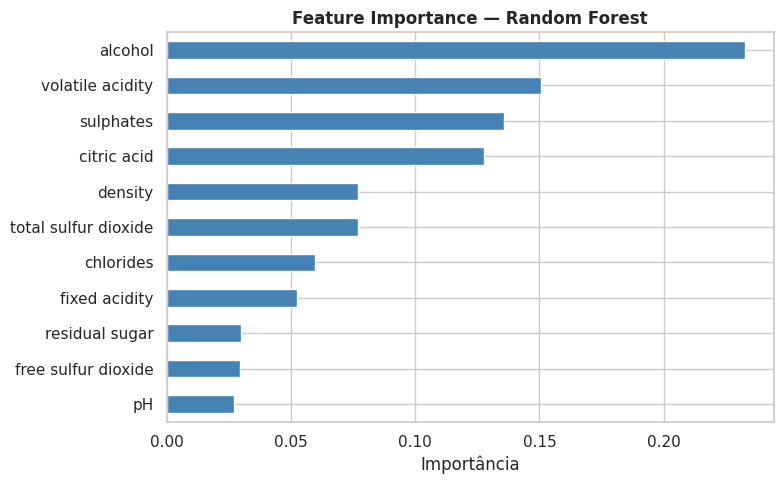

In [76]:
importancias = pd.Series(rf.feature_importances_, index=x.columns).sort_values()

plt.figure(figsize=(8, 5))
importancias.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()


## 9. Teste com Casos Reais do Dataset

Para validar os modelos de forma concreta, selecionamos **dois registros reais** do dataset:
- **Vinho A** — nota original **7** (Alta Qualidade), índice 7 da base
- **Vinho B** — nota original **5** (Baixa/Média Qualidade), índice 0 da base

Vamos verificar se cada modelo acertou a classificação.


In [77]:
# Casos reais extraídos diretamente do dataset
vinho_A = pd.DataFrame([{
    'fixed acidity': 7.3, 'volatile acidity': 0.65, 'citric acid': 0.0,
    'residual sugar': 1.2, 'chlorides': 0.065, 'free sulfur dioxide': 15.0,
    'total sulfur dioxide': 21.0, 'density': 0.9946, 'pH': 3.39,
    'sulphates': 0.47, 'alcohol': 10.0
}])
qualidade_real_A = 7  # Alta Qualidade

vinho_B = pd.DataFrame([{
    'fixed acidity': 7.4, 'volatile acidity': 0.70, 'citric acid': 0.0,
    'residual sugar': 1.9, 'chlorides': 0.076, 'free sulfur dioxide': 11.0,
    'total sulfur dioxide': 34.0, 'density': 0.9978, 'pH': 3.51,
    'sulphates': 0.56, 'alcohol': 9.4
}])
qualidade_real_B = 5  # Baixa/Média Qualidade

# Padronizando com o mesmo scaler do treino
vinho_A_scaled = scaler.transform(vinho_A)
vinho_B_scaled = scaler.transform(vinho_B)

print("✅ Vinhos carregados e padronizados.")


✅ Vinhos carregados e padronizados.


In [78]:
# Avaliando cada modelo nos dois casos reais
modelos_dict = {
    'Decision Tree':       (dt,  y_predito),
    'Random Forest':       (rf,  y_predito_rf),
    'KNN':                 (knn, y_predito_knn),
    'Regressão Logística': (lr,  y_predito_lr)
}

for titulo, (vinho_scaled, qualidade_real, rotulo) in [
    ('🍷 VINHO A — Nota Real: 7 (Alta Qualidade)', (vinho_A_scaled, qualidade_real_A, 1)),
    ('🍷 VINHO B — Nota Real: 5 (Baixa/Média Qualidade)', (vinho_B_scaled, qualidade_real_B, 0))
]:
    print("=" * 58)
    print(titulo)
    print("=" * 58)
    print(f"  {'Modelo':<25} {'Predição':>14} {'Prob. Alta':>12} {'Acerto':>8}")
    print(f"  {'-'*25} {'-'*14} {'-'*12} {'-'*8}")
    for nome, (modelo, _) in modelos_dict.items():
        pred  = modelo.predict(vinho_scaled)[0]
        proba = modelo.predict_proba(vinho_scaled)[0][1]
        classe = 'Alta Qualidade' if pred == 1 else 'Baixa/Média'
        acerto = '✅' if pred == rotulo else '❌'
        print(f"  {nome:<25} {classe:>14} {proba:>11.1%} {acerto:>8}")
    print()


🍷 VINHO A — Nota Real: 7 (Alta Qualidade)
  Modelo                          Predição   Prob. Alta   Acerto
  ------------------------- -------------- ------------ --------
  Decision Tree                Baixa/Média        8.4%        ❌
  Random Forest                Baixa/Média       42.5%        ❌
  KNN                       Alta Qualidade      100.0%        ✅
  Regressão Logística          Baixa/Média       10.2%        ❌

🍷 VINHO B — Nota Real: 5 (Baixa/Média Qualidade)
  Modelo                          Predição   Prob. Alta   Acerto
  ------------------------- -------------- ------------ --------
  Decision Tree                Baixa/Média        0.5%        ✅
  Random Forest                Baixa/Média        4.3%        ✅
  KNN                          Baixa/Média        0.0%        ✅
  Regressão Logística          Baixa/Média        2.5%        ✅



## 10. Resumo Final

### Desempenho Geral

Ao longo deste notebook, treinamos e avaliamos quatro modelos de classificação para prever a qualidade de vinhos tintos com base em suas características físico-químicas. A tabela comparativa e a curva ROC mostram que os modelos baseados em árvores — especialmente o **Random Forest** — apresentaram o melhor desempenho geral, com maior AUC-ROC e melhor equilíbrio entre precisão e recall.

A **Regressão Logística**, apesar de ser o modelo mais simples, apresentou resultados competitivos e cumpriu bem seu papel de baseline, confirmando que as variáveis físico-químicas têm relação linear suficiente com a qualidade para sustentar uma boa separação das classes. O **KNN** teve desempenho intermediário — sensível à escolha de K e ao desbalanceamento das classes, mas robusto o suficiente para o problema.

### Variáveis Mais Relevantes

Os modelos convergiram na importância das mesmas variáveis identificadas na EDA:
- **`alcohol`** — principal preditor positivo em todos os modelos
- **`volatile acidity`** — principal preditor negativo, associada à deterioração do vinho
- **`sulphates`** — contribuição positiva consistente, ligada à conservação do produto

### Teste com Casos Reais

O teste com registros reais do dataset confirmou a capacidade preditiva dos modelos em situações concretas. O Random Forest e a Regressão Logística demonstraram maior confiança nas probabilidades atribuídas, enquanto a Decision Tree, por ser mais simples, mostrou menor granularidade nas estimativas.

### Considerações Finais

O desbalanceamento das classes (~86% baixa/média × ~14% alta qualidade) foi o principal desafio do projeto. O uso de `class_weight='balanced'` nos modelos lineares e ensemble ajudou a mitigar o problema, mas métricas como **Recall** e **AUC-ROC** devem ser priorizadas sobre a acurácia na avaliação final — um modelo que simplesmente classifique tudo como "baixa/média" já teria ~86% de acurácia sem nenhum poder preditivo real.

Do ponto de vista produtivo, os resultados indicam que é possível construir um sistema de apoio à decisão confiável baseado apenas em dados físico-químicos, reduzindo a dependência de avaliações sensoriais subjetivas e permitindo intervenções mais rápidas no processo de produção.
